In [1]:
import pandas as pd
from db_queries import get_location_metadata
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import numpy as np
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import yaml

In [2]:
# Set paths ####################################################################
RAW_DATA_PATH = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/training_data/2026_09_13.01/data.parquet"
GBD_FILE = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/input/gbd_prevalence/gbd_mean_neonatal_mortality_prevalence.parquet"
INFERENCE_FILE_08_03 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_08_03.03/ssp245.parquet"  # Previous most-recent run
INFERENCE_FILE_09_14 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_09_14.01/ssp245.parquet"  # Consumption merged on birth year
INFERENCE_FILE_09_16 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_09_16.02/ssp245.parquet"  # linear fit on log consumption per day
INFERENCE_FILE_09_17 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_09_17.01/ssp245.parquet"  # linear fit on consumption per day
PLOT_OUTPUT = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/"

In [3]:
df_raw = pd.read_parquet(RAW_DATA_PATH)

# Add location names
locs = get_location_metadata(location_set_id=39, release_id=16)

df_raw = df_raw.merge(
    locs[["location_id", "location_name", "level", "super_region_name"]],
    on="location_id",
    how="left",
)

df_raw.head()

,year_start,year_end,nid,survey_name,int_year,int_month,sex_id,mothers_age_year,aod_months,age_month,...,q99_prev_9_mo_avg,zone,year_id,age_group_id,int_birth_year_diff_months,log_consumption_pd,sdi,location_name,level,super_region_name
0,2009,2010,13109,DHS_MIS,None,None,2,None,0,0,...,0.000000,23.0,2009,42,0,-0.245692,0.318291,Uganda,3,Sub-Saharan Africa
1,2022,2022,538795,None,2022,5,2,18,0,0,...,0.555556,24.0,2021,42,11,1.312609,0.447416,United Republic of Tanzania,3,Sub-Saharan Africa
2,2017,2017,353526,None,2017,4,1,20,0,0,...,1.222222,27.0,2017,42,0,2.448691,0.373539,Senegal,3,Sub-Saharan Africa
3,2019,2021,467681,DHS,None,None,1,None,0,0,...,0.000000,24.0,2020,42,2,1.619791,0.583046,India,3,South Asia
4,2000,2000,19156,None,2000,2,2,24,0,0,...,0.000000,25.0,1999,42,2,-0.227447,0.340183,Cambodia,3,"Southeast Asia, East Asia, and Oceania"


Scatters: 
averaged mortality by consumption_pd, 
averaged mortality by log_consumption_pd,
averaged mortality by sdi, 
averaged mortality by log_sdi

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/mortality_vs_covariates_scatter.pdf


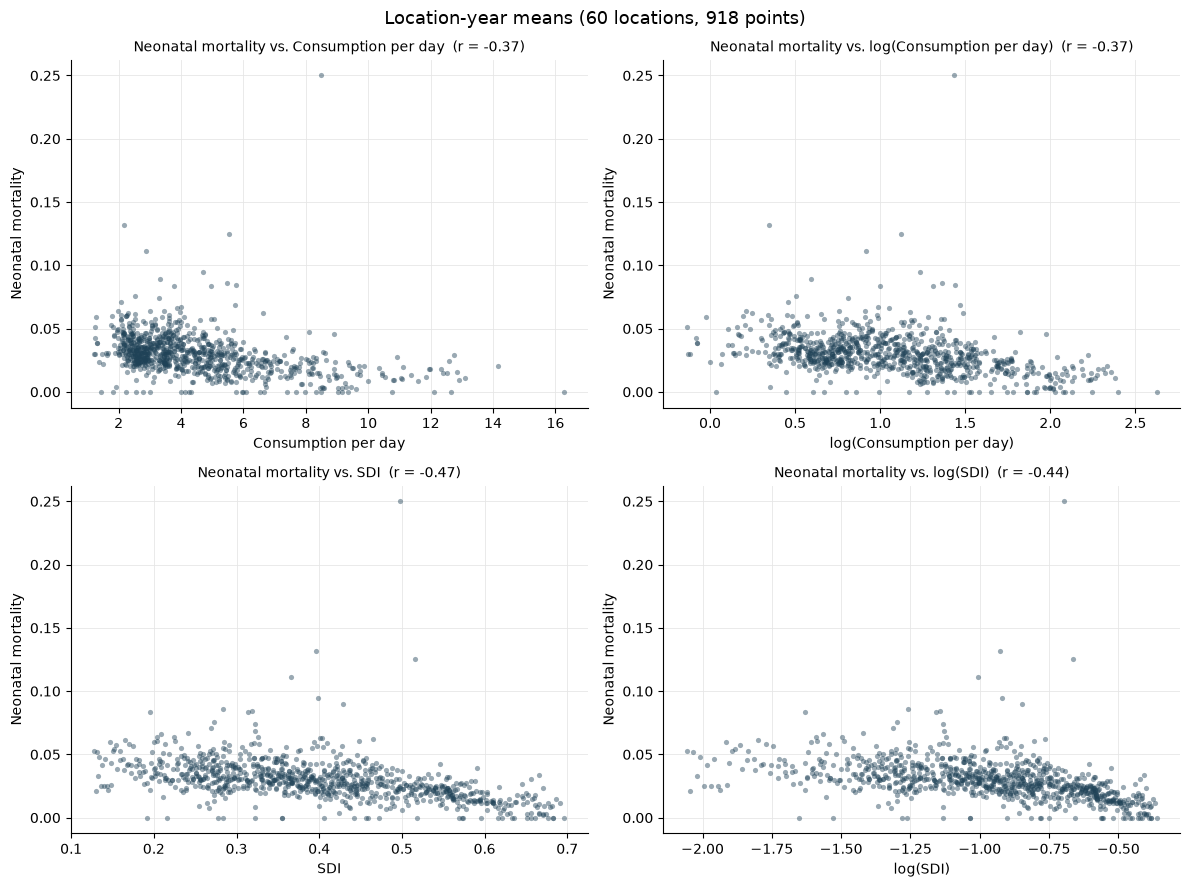

In [6]:
# Location-year means and mortality scatters ###################################
# Average the outcome and each covariate by location_name / birth_year, then
# scatter neonatal mortality against consumption_pd, log_consumption_pd, sdi and
# log_sdi. log_sdi is created here; log_consumption_pd already exists in the data.
MIN_OBS = 0  # set >0 (e.g. 25) to drop sparse location-years

df_raw["log_sdi"] = np.log(df_raw["sdi"])

AGG_VARS = [
    "neonatal_mortality",
    "consumption_pd",
    "log_consumption_pd",
    "sdi",
    "log_sdi",
]

df_agg = (
    df_raw.groupby(["location_name", "birth_year"])
    .agg(**{v: (v, "mean") for v in AGG_VARS}, n_births=("neonatal_mortality", "size"))
    .reset_index()
    .query("n_births >= @MIN_OBS")
)

scatter_specs = [
    ("consumption_pd", "Consumption per day"),
    ("log_consumption_pd", "log(Consumption per day)"),
    ("sdi", "SDI"),
    ("log_sdi", "log(SDI)"),
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
for ax, (x_col, x_label) in zip(axes.ravel(), scatter_specs):
    ax.scatter(
        df_agg[x_col],
        df_agg["neonatal_mortality"],
        s=14,
        alpha=0.45,
        color="#1f4257",
        linewidths=0,
    )
    r = df_agg[[x_col, "neonatal_mortality"]].corr().iloc[0, 1]
    ax.set_title(f"Neonatal mortality vs. {x_label}  (r = {r:.2f})", fontsize=10)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Neonatal mortality")
    ax.grid(True, color="0.9", linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

fig.suptitle(
    f"Location-year means ({df_agg['location_name'].nunique()} locations, "
    f"{len(df_agg)} points)",
    fontsize=13,
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}mortality_vs_covariates_scatter.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

Make scatters for 3 SSA countries only

Make more explanatory version of spline plot on Consumption

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/covariates_mortality_3countries.pdf


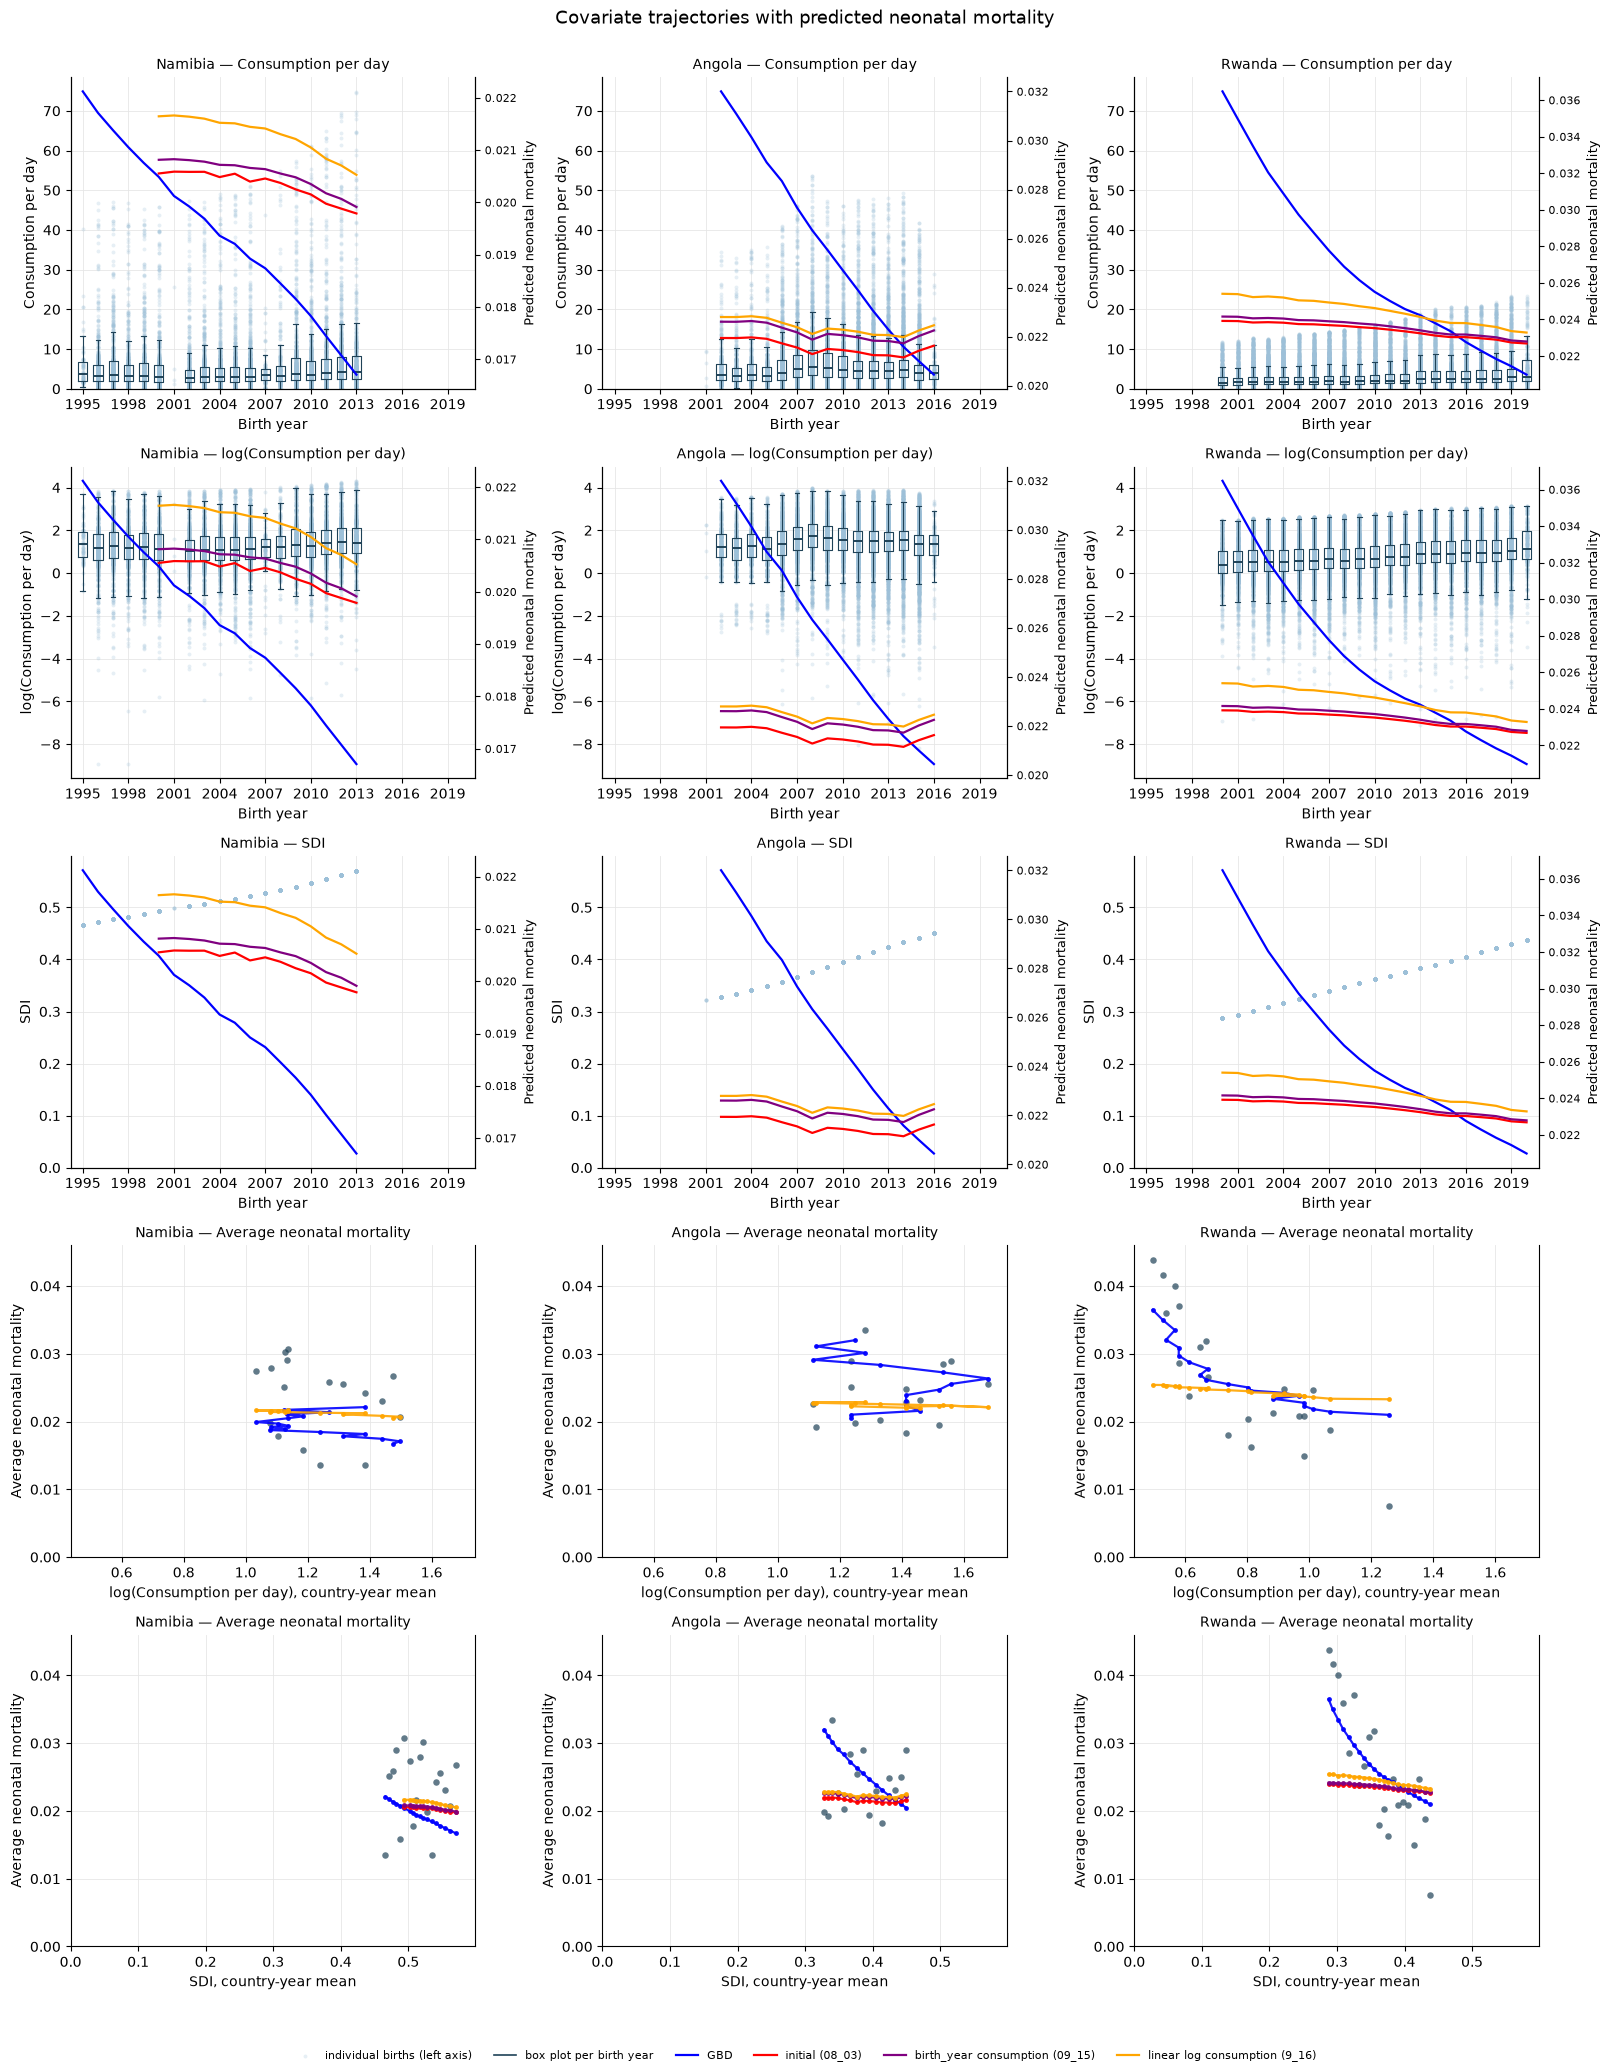

In [25]:
# Covariate trajectories with predicted mortality ##############################
# 3 rows x 3 columns, one column per country. Each row plots consumption_pd,
# log_consumption_pd or sdi against birth_year, with a box plot per birth year on
# the two consumption rows and a twin right axis carrying GBD and the two model
# runs (sex-averaged, clipped to the survey years). Axis limits are shared across
# the three countries and anchored at 0 where the variable is non-negative.
# A final row plots average neonatal mortality against mean log consumption per
# country-year, so it is drawn from country-year means rather than individual
# births and has no boxes, no time axis and no prediction overlay.
# ROW_VARS carries an x column per row; rows whose y column is in AGG_ROWS are
# plotted from df_cy (country-year means) instead of df_raw.
PRED_COLS = {
    "prevalence_gbd": ("blue", "GBD"),
    "prevalence_initial": ("red", "initial (08_03)"),
    "prevalence_birth_year_consumption": ("purple", "birth_year consumption (09_15)"),
    "prevalence_linear_log_consumption": ("orange", "linear log consumption (9_16)"),
}
countries = ["Namibia", "Angola", "Rwanda"]
# (x column, y column, x label, y label)
ROW_VARS = [
    ("birth_year", "consumption_pd", "Birth year", "Consumption per day"),
    ("birth_year", "log_consumption_pd", "Birth year", "log(Consumption per day)"),
    ("birth_year", "sdi", "Birth year", "SDI"),
    (
        "log_consumption_pd",
        "neonatal_mortality",
        "log(Consumption per day), country-year mean",
        "Average neonatal mortality",
    ),
    (
        "sdi",
        "neonatal_mortality",
        "SDI, country-year mean",
        "Average neonatal mortality",
    ),
]
AGG_ROWS = {"neonatal_mortality"}  # rows drawn from country-year means
# Series overlaid on each AGG_ROWS row, keyed by that row's x column; the
# birth_year rows always show all of PRED_COLS.
AGG_PRED_COLS = {
    "log_consumption_pd": ["prevalence_gbd", "prevalence_linear_log_consumption"],
    "sdi": list(PRED_COLS),
}
BOX_ROWS = {"consumption_pd", "log_consumption_pd"}  # rows that also get box plots
ZERO_ANCHOR_ROWS = {
    "consumption_pd",
    "sdi",
    "neonatal_mortality",
}  # log_consumption_pd goes negative
MIN_OBS = 25  # birth-years with fewer births than this get no box
YMAX_QUANTILE = 1.0  # shared left-axis extent; lower it (e.g. 0.99) to tighten
POINT_COLOR = "#9dc0d8"
BOX_COLOR = "#1f4257"


def get_mean_draw(data):
    draw_cols = [c for c in data.columns if c.startswith("draw_")]
    out = data[[c for c in data.columns if "draw_" not in c]].copy()
    out["prevalence"] = data[draw_cols].mean(axis=1)
    return out


# Predictions ##################################################################
key = ["location_id", "year_id", "sex_id"]
gbd = (
    pd.read_parquet(GBD_FILE)
    .reset_index()
    .rename(columns={"gbd_mean_prevalence": "prevalence_gbd"})
)
init = get_mean_draw(pd.read_parquet(INFERENCE_FILE_08_03).reset_index()).rename(
    columns={"prevalence": "prevalence_initial"}
)
lin = get_mean_draw(pd.read_parquet(INFERENCE_FILE_09_14).reset_index()).rename(
    columns={"prevalence": "prevalence_birth_year_consumption"}
)
loglin = get_mean_draw(pd.read_parquet(INFERENCE_FILE_09_16).reset_index()).rename(
    columns={"prevalence": "prevalence_linear_log_consumption"}
)

pred = (
    gbd[key + ["prevalence_gbd"]]
    .merge(init[key + ["prevalence_initial"]], on=key, how="left")
    .merge(lin[key + ["prevalence_birth_year_consumption"]], on=key, how="left")
    .merge(loglin[key + ["prevalence_linear_log_consumption"]], on=key, how="left")
    .merge(locs[["location_id", "location_name"]], on="location_id", how="left")
)
pred = (
    pred[pred["location_name"].isin(countries)]
    .groupby(["location_name", "year_id"], as_index=False)[list(PRED_COLS)]
    .mean()
)

# Country-year means, used by the AGG_ROWS rows ################################
selected = df_raw[df_raw["location_name"].isin(countries)]
df_cy = (
    selected.groupby(["location_name", "birth_year"], as_index=False)
    .agg(
        neonatal_mortality=("neonatal_mortality", "mean"),
        consumption_pd=("consumption_pd", "mean"),
        log_consumption_pd=("log_consumption_pd", "mean"),
        sdi=("sdi", "mean"),
        n_births=("neonatal_mortality", "size"),
    )
    .query("n_births >= @MIN_OBS")
)

# Predictions placed on a covariate x axis, for the AGG_ROWS rows ##############
pred_cy = pred.merge(
    df_cy.rename(columns={"birth_year": "year_id"}).drop(
        columns=["neonatal_mortality", "n_births"]
    ),
    on=["location_name", "year_id"],
    how="inner",
)

# Shared year limits for every birth_year row ##################################
year_counts = selected.groupby(["location_name", "birth_year"]).size()
kept = year_counts[year_counts >= MIN_OBS].index.get_level_values("birth_year")
year_lim = (kept.min() - 0.8, kept.max() + 0.8)


# Axis limits, shared across the three countries ###############################
def _limits(series, anchor_zero):
    hi = float(series.quantile(YMAX_QUANTILE))
    lo = 0.0 if anchor_zero else float(series.quantile(1 - YMAX_QUANTILE))
    pad = 0.05 * (hi - lo)
    return (lo if anchor_zero else lo - pad, hi + pad)


row_lims = []
for x_col, y_col, _, _ in ROW_VARS:
    source = df_cy if y_col in AGG_ROWS else selected
    y_values = source[y_col]
    if y_col in AGG_ROWS:
        # the prediction lines live on this same axis, so include their range
        y_values = pd.concat([y_values, pred_cy[AGG_PRED_COLS[x_col]].stack()])
    ylim = _limits(y_values, y_col in ZERO_ANCHOR_ROWS)
    xlim = (
        None
        if x_col == "birth_year"
        else _limits(source[x_col], x_col in ZERO_ANCHOR_ROWS)
    )
    row_lims.append((xlim, ylim))

# Plot #########################################################################
fig, axes = plt.subplots(
    nrows=len(ROW_VARS),
    ncols=len(countries),
    figsize=(5.4 * len(countries), 4.2 * len(ROW_VARS)),
)
axes = np.atleast_2d(axes)
handles, labels = [], []

for row, (x_col, y_col, x_label, y_label) in enumerate(ROW_VARS):
    for col, country in enumerate(countries):
        ax = axes[row, col]
        aggregated = y_col in AGG_ROWS
        source = df_cy if aggregated else df_raw
        sub = source[source["location_name"] == country]
        ax.scatter(
            sub[x_col],
            sub[y_col],
            s=22 if aggregated else 8,
            alpha=0.7 if aggregated else 0.25,
            color=BOX_COLOR if aggregated else POINT_COLOR,
            linewidths=0,
            zorder=1,
            label="individual births (left axis)",
        )

        counts = sub.groupby("birth_year").size()
        kept_years = counts[counts >= MIN_OBS].index

        if x_col == "birth_year" and y_col in BOX_ROWS and len(kept_years):
            positions = list(kept_years)
            distributions = [
                sub.loc[sub["birth_year"] == yr, y_col].dropna().to_numpy()
                for yr in positions
            ]
            ax.boxplot(
                distributions,
                positions=positions,
                widths=0.6,
                manage_ticks=False,
                showfliers=False,
                zorder=2,
                boxprops={"color": BOX_COLOR, "linewidth": 0.8},
                whiskerprops={"color": BOX_COLOR, "linewidth": 0.8},
                capprops={"color": BOX_COLOR, "linewidth": 0.8},
                medianprops={"color": BOX_COLOR, "linewidth": 1.4},
            )

        if x_col == "birth_year":
            y0, y1 = kept_years.min(), kept_years.max()
            p = pred[
                (pred["location_name"] == country) & pred["year_id"].between(y0, y1)
            ].sort_values("year_id")

            ax2 = ax.twinx()
            for pred_col, (color, label) in PRED_COLS.items():
                ax2.plot(
                    p["year_id"],
                    p[pred_col],
                    color=color,
                    lw=1.6,
                    zorder=3,
                    label=label,
                )
            ax2.set_ylabel("Predicted neonatal mortality", fontsize=9)
            ax2.tick_params(labelsize=8)
            ax2.spines["top"].set_visible(False)
            ax.set_xlim(*year_lim)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            if not handles:
                h1, l1 = ax.get_legend_handles_labels()
                h2, l2 = ax2.get_legend_handles_labels()
                handles, labels = h1 + h2, l1 + l2
                if BOX_ROWS:
                    handles.insert(1, plt.Line2D([], [], color=BOX_COLOR, lw=1.2))
                    labels.insert(1, "box plot per birth year")
        else:
            ax.set_xlim(*row_lims[row][0])
            # y is already mortality here, so the predictions share the left axis
            pm = pred_cy[pred_cy["location_name"] == country].sort_values("year_id")
            for pred_col in AGG_PRED_COLS[x_col]:
                color, label = PRED_COLS[pred_col]
                ax.plot(
                    pm[x_col],
                    pm[pred_col],
                    color=color,
                    lw=1.6,
                    marker="o",
                    ms=2.5,
                    alpha=0.9,
                    zorder=3,
                    label=label,
                )

        ax.set_ylim(*row_lims[row][1])
        ax.set_title(f"{country} — {y_label}", fontsize=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, color="0.9", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)

fig.legend(
    handles, labels, loc="lower center", ncol=len(labels), fontsize=8, frameon=False
)
fig.suptitle(
    "Covariate trajectories with predicted neonatal mortality",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0.03, 1, 0.98))

plot_path = f"{PLOT_OUTPUT}covariates_mortality_3countries.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

In [ ]:
# Parametric (non-spline) coefficients for a completed run #####################
# base_model_coefs.parquet holds only the parametric terms; spline terms live in
# the separate *_spline_effects.parquet files and the country random intercept
# lives in base_model_ranef.parquet. The model version is read from the results
# spec rather than assumed, since results and model versions usually differ.
MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)


def print_model_coefficients(inference_file, label=""):
    results_dir = Path(inference_file).parent
    model_version = yaml.safe_load((results_dir / "results_spec.yaml").read_text())[
        "version"
    ]["model"]
    model_dir = MODEL_ROOT / model_version
    spec = yaml.safe_load((model_dir / "specification.yaml").read_text())
    coefs = pd.read_parquet(model_dir / "base_model_coefs.parquet")
    ranef = pd.read_parquet(model_dir / "base_model_ranef.parquet")

    spline_terms = [p["name"] for p in spec["predictors"] if p.get("spline")]
    print(f"{label or results_dir.name}  ->  model {model_version}")
    print(f"  predictors    : {[p['name'] for p in spec['predictors']]}")
    print(f"  spline terms  : {spline_terms or 'none'}  (not in the table below)")
    print(f"  random effect : {len(ranef)} {ranef.index.name} offsets")
    print(coefs.to_string())
    print()
    return coefs

In [ ]:
print_model_coefficients(INFERENCE_FILE_09_16, "linear log consumption (9_16)")

linear log consumption (9_16)  ->  model 2026_09_16.02
  predictors    : ['intercept', 'sex_id', 'birth_year', 'consumption_pd']
  spline terms  : none  (not in the table below)
  random effect : 60 ihme_loc_id offsets
                 Estimate  std_error  statistic        p_value
term                                                          
(Intercept)     34.690024   1.550822  22.368798  7.924268e-111
C(sex_id)2      -0.262168   0.009053 -28.959009  2.161289e-184
birth_year      -0.018961   0.000772 -24.558602  3.500320e-133
consumption_pd  -0.126393   0.005570 -22.691124  5.481930e-114



,Estimate,std_error,statistic,p_value
term,,,,
(Intercept),34.690024,1.550822,22.368798,7.924268e-111
C(sex_id)2,-0.262168,0.009053,-28.959009,2.161289e-184
birth_year,-0.018961,0.000772,-24.558602,3.500320e-133
consumption_pd,-0.126393,0.005570,-22.691124,5.481930e-114


In [ ]:
print_model_coefficients(INFERENCE_FILE_09_14, "consumption merged on birth_year")

consumption merged on birth_year  ->  model 2026_09_14.02
  predictors    : ['intercept', 'sex_id', 'birth_year', 'consumption_pd']
  spline terms  : ['consumption_pd']  (not in the table below)
  random effect : 60 ihme_loc_id offsets
              Estimate  std_error  statistic        p_value
term                                                       
(Intercept)  33.156943   1.558413  21.276097  1.890408e-100
C(sex_id)2   -0.262638   0.009054 -29.007687  5.263294e-185
birth_year   -0.018271   0.000775 -23.580155  6.160273e-123



,Estimate,std_error,statistic,p_value
term,,,,
(Intercept),33.156943,1.558413,21.276097,1.890408e-100
C(sex_id)2,-0.262638,0.009054,-29.007687,5.263294e-185
birth_year,-0.018271,0.000775,-23.580155,6.160273e-123


Make updates of spline plots, based off /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/models/2026_09_14.02/spline_effect_consumption_pd.png

2026_09_14.02: z0 = -3.7513 at birth_year=2020, reference sex, average country (ranef mean 0.000000)
  mortality at partial effect 0 = 2.295%
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/spline_effect_consumption_pd_with_mortality.pdf


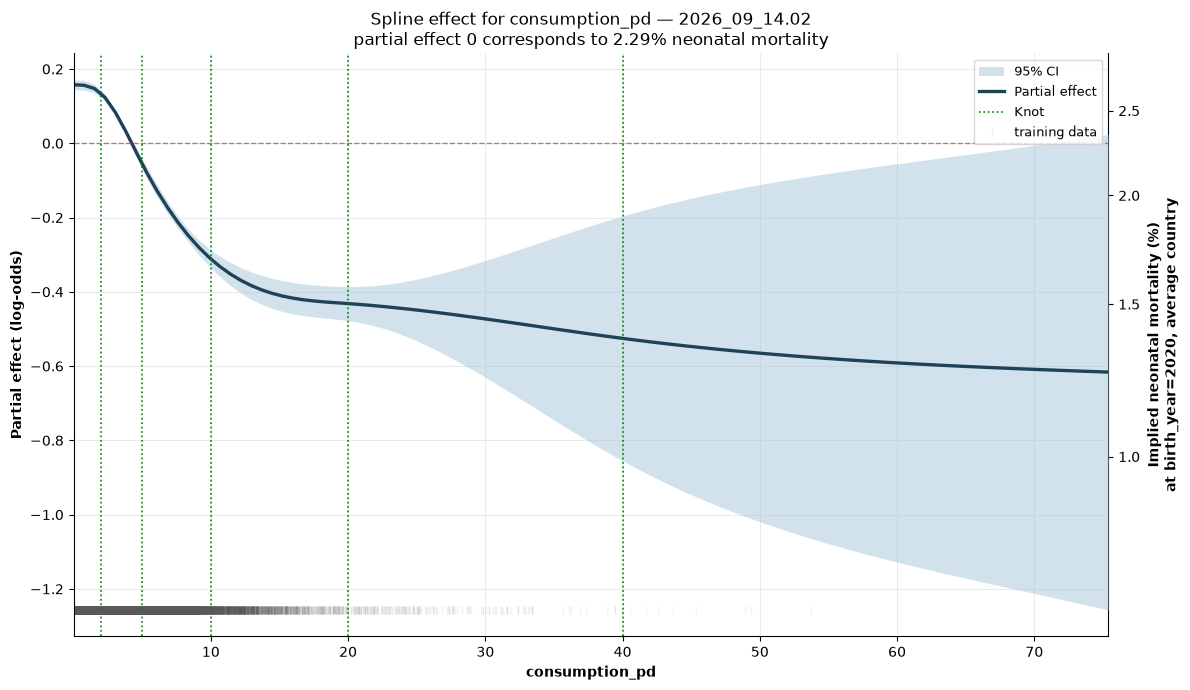

 consumption_pd  partial_effect  implied_nmr_pct  pct_change_vs_$1
            0.5           0.157            2.674             0.321
            1.0           0.153            2.665             0.000
            2.0           0.132            2.611            -2.025
            5.0          -0.055            2.174           -18.437
           10.0          -0.311            1.691           -36.541
           20.0          -0.432            1.502           -43.629
           40.0          -0.525            1.370           -48.600
           75.0          -0.616            1.253           -52.983


In [27]:
# Spline effect with the implied neonatal mortality on a second axis ###########
# Redraws models/<version>/spline_effect_<predictor>.png with a right-hand axis
# giving the neonatal mortality each log-odds value implies.
#
# The partial effect is an offset on the logit scale, so turning it into a
# mortality percentage needs a reference point for everything else in the model.
# We use the model's own linear predictor with the spline contribution set aside:
#   z0 = intercept + birth_year_coef * BASELINE_BIRTH_YEAR
# at the reference sex and an average country (the random intercepts are
# mean-zero, checked below). Implied mortality is then expit(z0 + effect), an
# exact monotone transform of the left axis, so the two axes stay in register.

MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
SPLINE_MODEL_VERSION = "2026_09_14.02"
SPLINE_PREDICTOR = "consumption_pd"
BASELINE_BIRTH_YEAR = 2020
RUG_SAMPLE = 20000

model_dir = MODEL_ROOT / SPLINE_MODEL_VERSION
spline = pd.read_parquet(model_dir / f"spline_effect_{SPLINE_PREDICTOR}.parquet")
coefs = pd.read_parquet(model_dir / "base_model_coefs.parquet")["Estimate"]
ranef = pd.read_parquet(model_dir / "base_model_ranef.parquet")
spec = yaml.safe_load((model_dir / "specification.yaml").read_text())
knots = [
    k
    for p in spec["predictors"]
    if p["name"] == SPLINE_PREDICTOR and p.get("spline")
    for k in p["spline"]["knots"]
]

z0 = float(coefs["(Intercept)"] + coefs["birth_year"] * BASELINE_BIRTH_YEAR)
baseline_nmr = 1 / (1 + np.exp(-z0))
print(
    f"{SPLINE_MODEL_VERSION}: z0 = {z0:.4f} at birth_year={BASELINE_BIRTH_YEAR}, "
    f"reference sex, average country (ranef mean {ranef.iloc[:, 0].mean():.6f})"
)
print(f"  mortality at partial effect 0 = {100 * baseline_nmr:.3f}%")


def logodds_to_pct(logodds):
    return 100 / (1 + np.exp(-(z0 + np.asarray(logodds, dtype=float))))


def pct_to_logodds(pct):
    p = np.clip(np.asarray(pct, dtype=float) / 100, 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p)) - z0


lo = spline["effect"] - 1.96 * spline["se"]
hi = spline["effect"] + 1.96 * spline["se"]

fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(
    spline["value"], lo, hi, color="#9dc0d8", alpha=0.45, linewidth=0, label="95% CI"
)
ax.plot(
    spline["value"], spline["effect"], color="#1f4257", lw=2.4, label="Partial effect"
)
ax.axhline(0, color="#d1495b", lw=1, ls="--", alpha=0.8)
for i, knot in enumerate(knots):
    ax.axvline(knot, color="green", ls=":", lw=1.2, label="Knot" if i == 0 else None)

rug = df_raw.loc[df_raw[SPLINE_PREDICTOR].notna(), SPLINE_PREDICTOR]
rug = rug.sample(min(RUG_SAMPLE, len(rug)), random_state=0)
ax.plot(
    rug,
    np.full(len(rug), lo.min()),
    "|",
    color="0.35",
    ms=6,
    alpha=0.08,
    label="training data",
)

ax.set_xlim(spline["value"].min(), spline["value"].max())
ax.set_xlabel(SPLINE_PREDICTOR, fontweight="bold")
ax.set_ylabel("Partial effect (log-odds)", fontweight="bold")
ax.grid(True, color="0.9", linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

pct_axis = ax.secondary_yaxis("right", functions=(logodds_to_pct, pct_to_logodds))
pct_axis.set_ylabel(
    f"Implied neonatal mortality (%)\n"
    f"at birth_year={BASELINE_BIRTH_YEAR}, average country",
    fontweight="bold",
)

ax.legend(loc="upper right", fontsize=9)
ax.set_title(
    f"Spline effect for {SPLINE_PREDICTOR} — {SPLINE_MODEL_VERSION}\n"
    f"partial effect 0 corresponds to {100 * baseline_nmr:.2f}% neonatal mortality",
    fontsize=12,
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}spline_effect_{SPLINE_PREDICTOR}_with_mortality.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Reference table over the fitted range
table = pd.DataFrame({"consumption_pd": [0.5, 1, 2, 5, 10, 20, 40, 75]})
table["partial_effect"] = np.interp(
    table["consumption_pd"], spline["value"], spline["effect"]
)
table["implied_nmr_pct"] = logodds_to_pct(table["partial_effect"])
table["pct_change_vs_$1"] = 100 * (
    table["implied_nmr_pct"]
    / logodds_to_pct(np.interp(1, spline["value"], spline["effect"]))
    - 1
)
print(table.round(3).to_string(index=False))

note: Namibia inference grid starts 2000, so its first endpoint is 2000 rather than 1995
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/spline_effect_consumption_pd_by_country_four_views.pdf


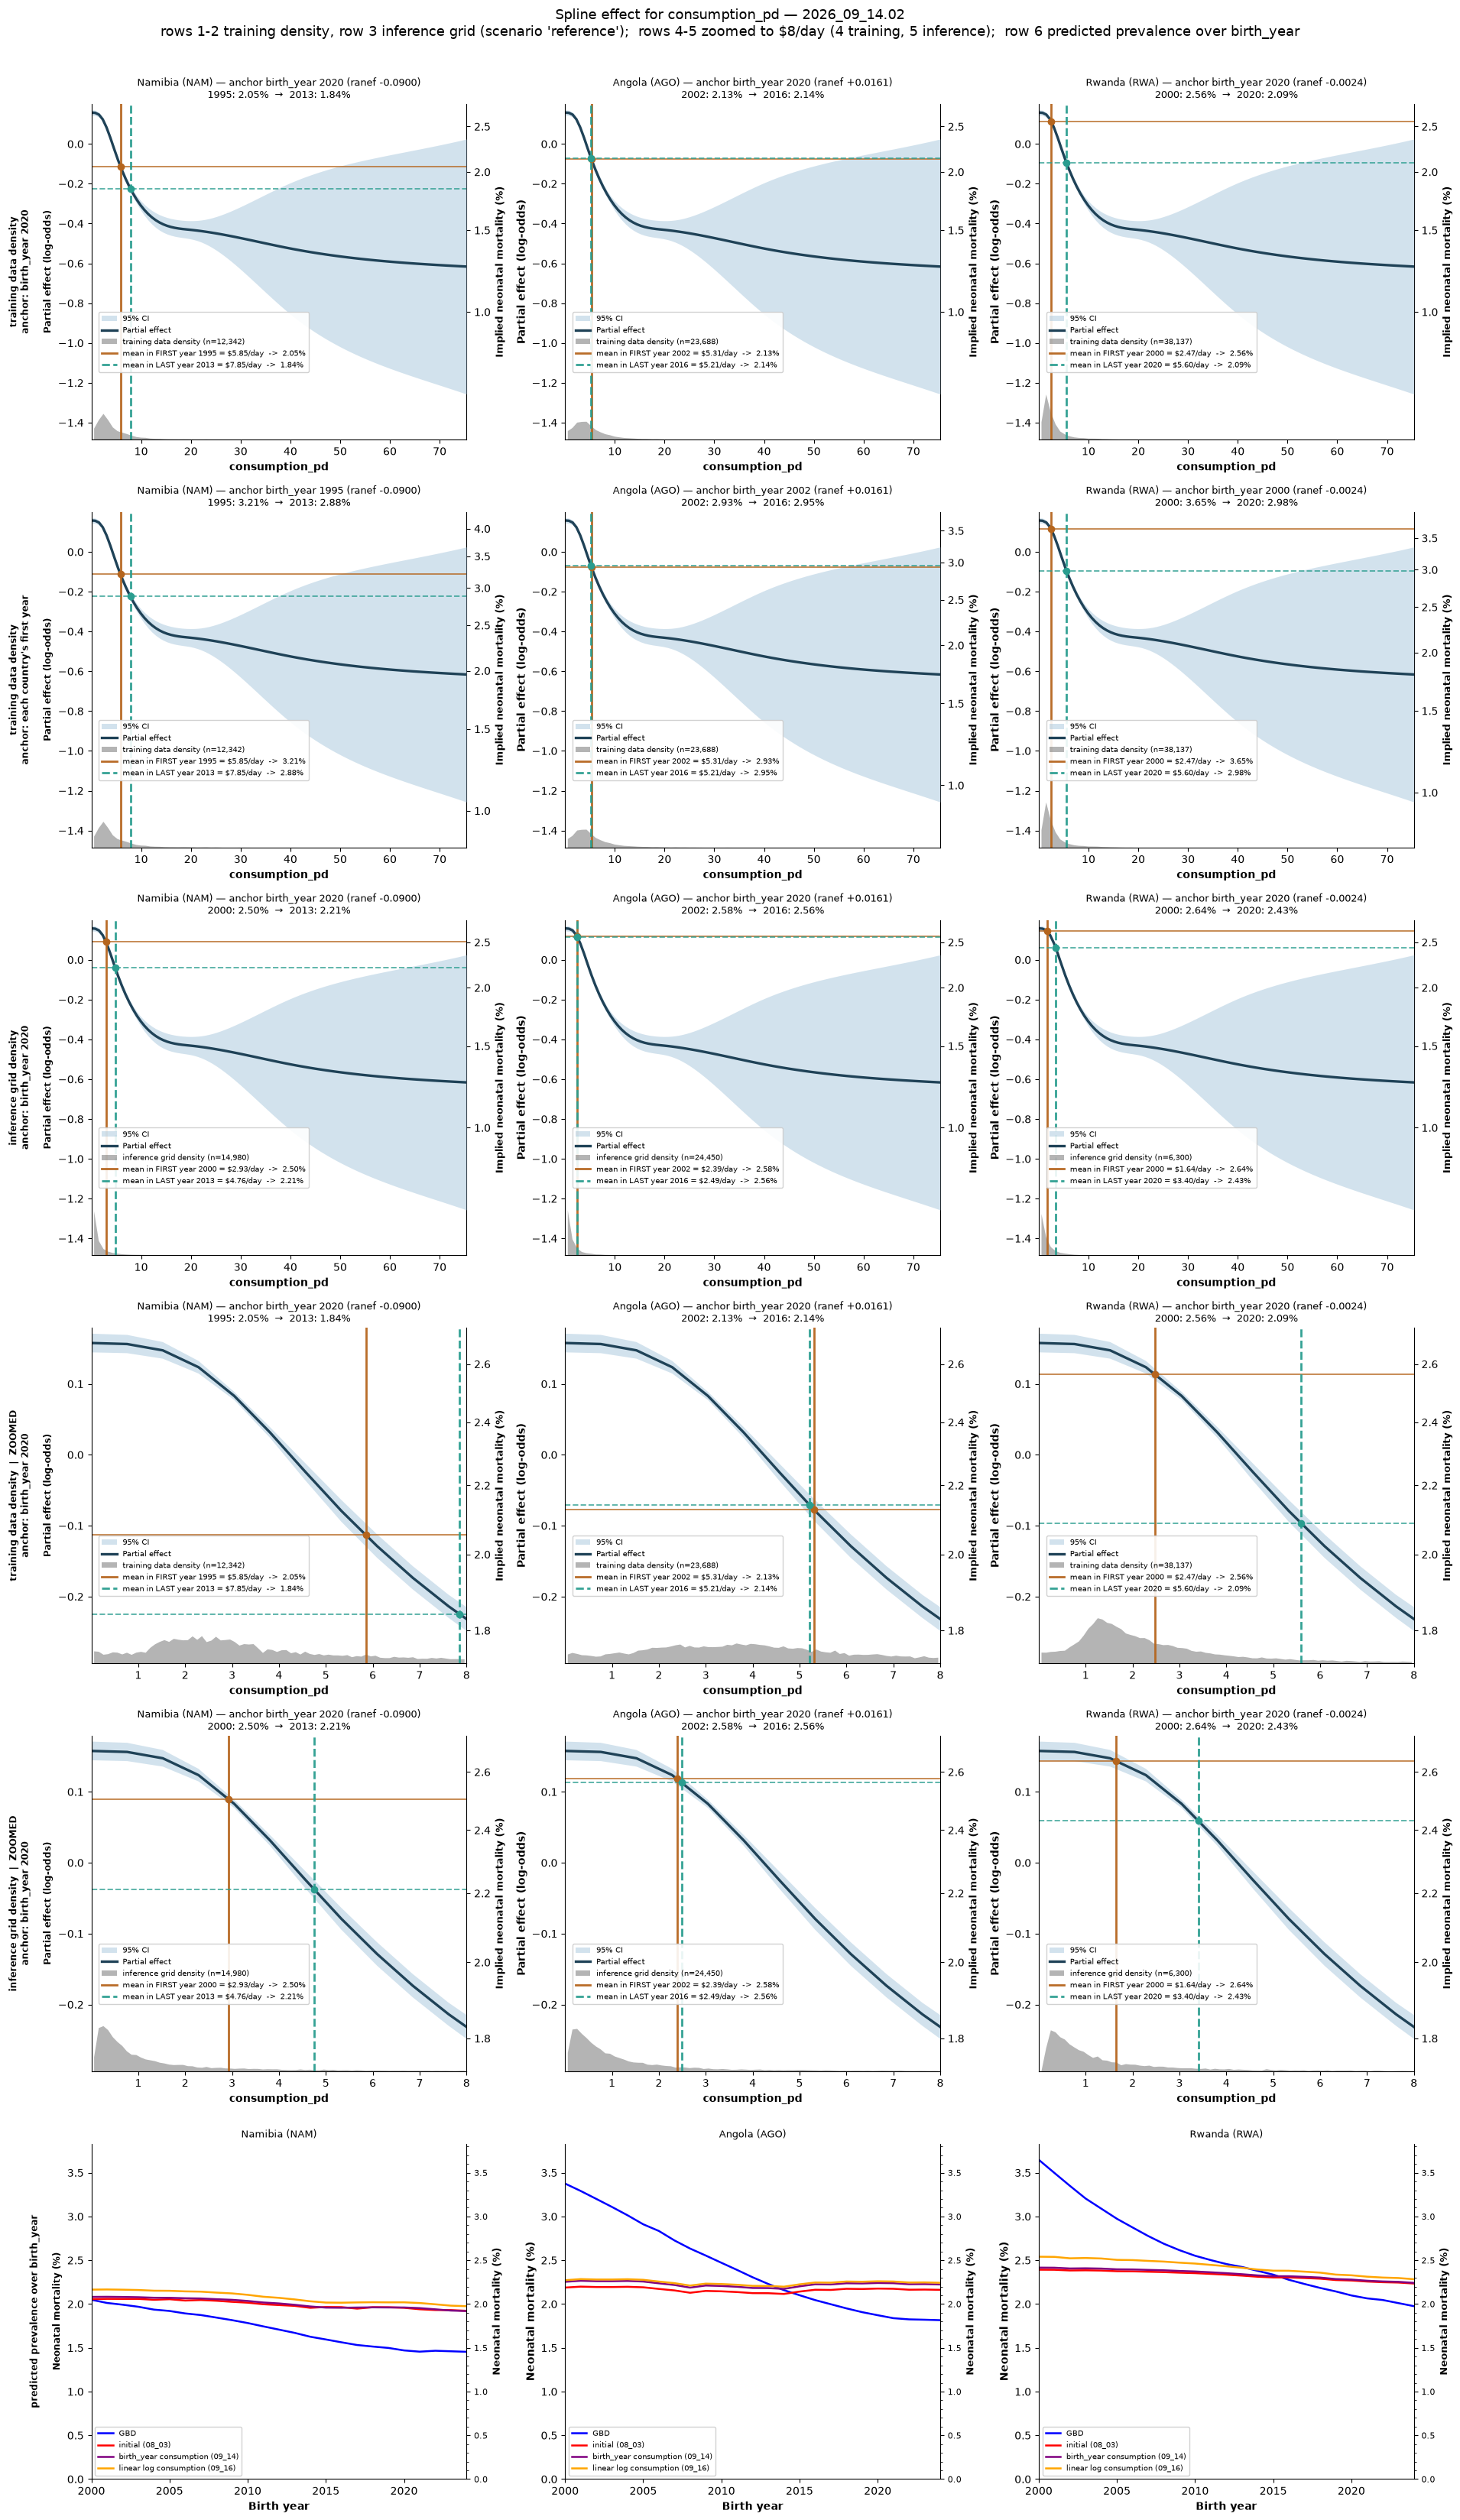

   source country  first_year  first_mean  last_year  last_mean  nmr_first_pct  nmr_last_pct  pct_change
 training Namibia        1995       5.851       2013      7.849          2.054         1.842     -10.359
 training  Angola        2002       5.307       2016      5.214          2.127         2.141       0.654
 training  Rwanda        2000       2.474       2020      5.597          2.563         2.088     -18.545
inference Namibia        2000       2.932       2013      4.758          2.503         2.211     -11.683
inference  Angola        2002       2.386       2016      2.487          2.575         2.562      -0.521
inference  Rwanda        2000       1.641       2020      3.403          2.640         2.431      -7.924


In [8]:
# Spline effect per country, four views ########################################
# The fitted curve is a global fixed effect, so it is identical in every panel.
# What varies by row is set in ROW_SPECS:
#   * anchor - the reference birth year for the right-hand mortality axis,
#         z0 = intercept + birth_year_coef * anchor_year + ranef[country]
#     "common" uses SPLINE_COMMON_YEAR for every country, "first" uses each
#     country's own first year of data, which shows how much of the mortality
#     level the birth_year term alone is carrying.
#   * zoom - restrict x to ZOOM_XMAX so the intersections are legible where the
#     data actually sits, instead of spanning the whole fitted range.
#   * source - which distribution the density band and the mean lines come from:
#     "training" is individual births in the training data, "inference" is the
#     admin2 x income-decile grid the model is applied to at inference.
# Two vertical lines mark the mean consumption in that country's first and last
# year of data, each paired with a horizontal line at the partial effect the
# curve takes there and a dot on the intersection.
from pathlib import Path

import yaml
from matplotlib.ticker import AutoMinorLocator

SPLINE_MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
SPLINE_MODEL = "2026_09_14.02"
SPLINE_VAR = "consumption_pd"
SPLINE_COMMON_YEAR = 2020
SPLINE_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
SPLINE_MIN_OBS = 25  # a year needs this many births to count as first/last
SPLINE_SCENARIO = "reference"  # income scenario in the inference grid
ZOOM_XMAX = 8.0
# The right-hand axis is z0 = intercept + birth_year_coef * anchor_year, plus the
# country random intercept only if INCLUDE_RANEF. Leaving it out makes z0 - and
# so the mortality axis - identical across the three columns wherever the anchor
# year is shared, at the cost of reading "average country" rather than that
# country. The offsets are small (|ranef| <= 0.09) and still shown in the title.
INCLUDE_RANEF = False
DENSITY_BINS = 80
DENSITY_FRAC = 0.16  # share of the panel height given to the density band

FIRST_COLOR, LAST_COLOR = "#b5651d", "#2a9d8f"
ROW_SPECS = [
    ("common", False, "training"),
    ("first", False, "training"),
    ("common", False, "inference"),
    ("common", True, "training"),
    ("common", True, "inference"),
    ("common", False, "timeseries"),
]
SOURCE_LABEL = {
    "training": "training data",
    "inference": "inference grid",
    "timeseries": "predicted prevalence over birth_year",
}
# Series for the timeseries row, sex-averaged. Note the 09_14 label: cell 8 calls
# this one "(09_15)", but INFERENCE_FILE_09_14 is what it reads.
TS_SERIES = {
    "prevalence_gbd": (GBD_FILE, "blue", "GBD"),
    "prevalence_initial": (INFERENCE_FILE_08_03, "red", "initial (08_03)"),
    "prevalence_birth_year_consumption": (
        INFERENCE_FILE_09_14,
        "purple",
        "birth_year consumption (09_14)",
    ),
    "prevalence_linear_log_consumption": (
        INFERENCE_FILE_09_16,
        "orange",
        "linear log consumption (09_16)",
    ),
}

_dir = SPLINE_MODEL_ROOT / SPLINE_MODEL
_spline = pd.read_parquet(_dir / f"spline_effect_{SPLINE_VAR}.parquet")
_coefs = pd.read_parquet(_dir / "base_model_coefs.parquet")["Estimate"]
_ranef = pd.read_parquet(_dir / "base_model_ranef.parquet")
_spec = yaml.safe_load((_dir / "specification.yaml").read_text())
_iso = locs.set_index("location_name")["ihme_loc_id"]


def _effect_at(value):
    return float(np.interp(value, _spline["value"], _spline["effect"]))


# Training data: first/last year with enough births, and the mean in each #######
_by_year = (
    df_raw[df_raw["location_name"].isin(SPLINE_COUNTRIES)]
    .groupby(["location_name", "birth_year"])
    .agg(n=(SPLINE_VAR, "size"), mean=(SPLINE_VAR, "mean"))
    .query("n >= @SPLINE_MIN_OBS")
)
_years = {}
for country in SPLINE_COUNTRIES:
    yrs = _by_year.loc[country].index
    _years[country] = (int(yrs.min()), int(yrs.max()))

# Inference grid: the same covariate the model is applied to ###################
_grid = pd.read_parquet(
    _dir / f"base_model_{SPLINE_VAR}_spline_effects.parquet",
    columns=[
        "year_id",
        "national_ihme_loc_id",
        "population_percentile",
        "scenario",
        "value",
    ],
    filters=[
        ("scenario", "==", SPLINE_SCENARIO),
        ("national_ihme_loc_id", "in", [_iso.loc[c] for c in SPLINE_COUNTRIES]),
    ],
)
_grid = _grid[_grid["population_percentile"] > 0]
_grid_min_year = int(_grid["year_id"].min())

# Per-country distributions and endpoint means, for each source ################
_dists, _endpoints = {}, {}
for country in SPLINE_COUNTRIES:
    iso = _iso.loc[country]
    first, last = _years[country]

    train = df_raw.loc[df_raw["location_name"] == country, SPLINE_VAR].dropna()
    _dists[("training", country)] = train
    _endpoints[("training", country)] = {
        "first_year": first,
        "last_year": last,
        "first_mean": float(_by_year.loc[(country, first), "mean"]),
        "last_mean": float(_by_year.loc[(country, last), "mean"]),
    }

    g = _grid[_grid["national_ihme_loc_id"] == iso]
    # the grid starts later than some surveys, so clamp the early endpoint
    g_first, g_last = max(first, _grid_min_year), last
    _dists[("inference", country)] = g.loc[
        g["year_id"].between(g_first, g_last), "value"
    ]
    _endpoints[("inference", country)] = {
        "first_year": g_first,
        "last_year": g_last,
        "first_mean": float(g.loc[g["year_id"] == g_first, "value"].mean()),
        "last_mean": float(g.loc[g["year_id"] == g_last, "value"].mean()),
    }
    if g_first != first:
        print(
            f"note: {country} inference grid starts {_grid_min_year}, "
            f"so its first endpoint is {g_first} rather than {first}"
        )


# Predicted prevalence by country and year, sex-averaged, for the last row #####
def _mean_draw(frame):
    draw_cols = [c for c in frame.columns if c.startswith("draw_")]
    out = frame[[c for c in frame.columns if "draw_" not in c]].copy()
    out["prevalence"] = frame[draw_cols].mean(axis=1)
    return out


_ts = None
for col, (path, _colour, _label) in TS_SERIES.items():
    frame = pd.read_parquet(path).reset_index()
    if col != "prevalence_gbd":
        frame = _mean_draw(frame)
        frame = frame.rename(columns={"prevalence": col})
    else:
        frame = frame.rename(columns={"gbd_mean_prevalence": col})
    frame = frame[["location_id", "year_id", "sex_id", col]]
    _ts = (
        frame
        if _ts is None
        else _ts.merge(frame, on=["location_id", "year_id", "sex_id"], how="inner")
    )
_ts = (
    _ts.merge(locs[["location_id", "location_name"]], on="location_id", how="left")
    .query("location_name in @SPLINE_COUNTRIES")
    .groupby(["location_name", "year_id"], as_index=False)[list(TS_SERIES)]
    .mean()
)
_ts_xlim = (_ts["year_id"].min(), _ts["year_id"].max())
_ts_ylim = (
    0.0,
    100 * _ts[list(TS_SERIES)].to_numpy().max() * 1.05,
)

# Density bands, normalised within each (source, zoom) so rows stay comparable #
_edges = {
    False: np.linspace(
        _spline["value"].min(), _spline["value"].max(), DENSITY_BINS + 1
    ),
    True: np.linspace(_spline["value"].min(), ZOOM_XMAX, DENSITY_BINS + 1),
}
_bands, _band_max = {}, {}
for source in ("training", "inference"):
    for zoom in (False, True):
        for country in SPLINE_COUNTRIES:
            _bands[(source, zoom, country)] = np.histogram(
                _dists[(source, country)], bins=_edges[zoom], density=True
            )[0]
        _band_max[(source, zoom)] = max(
            _bands[(source, zoom, c)].max() for c in SPLINE_COUNTRIES
        )

# Panel limits, per zoom setting ###############################################
_lo_all = _spline["effect"] - 1.96 * _spline["se"]
_hi_all = _spline["effect"] + 1.96 * _spline["se"]
_limits = {}
for zoom in (False, True):
    keep = _spline["value"] <= (ZOOM_XMAX if zoom else _spline["value"].max())
    lo, hi = _lo_all[keep].min(), _hi_all[keep].max()
    span = hi - lo
    _limits[zoom] = (lo - DENSITY_FRAC * span, hi + 0.02 * span, span)

fig, axes = plt.subplots(
    nrows=len(ROW_SPECS),
    ncols=len(SPLINE_COUNTRIES),
    figsize=(6.4 * len(SPLINE_COUNTRIES), 5.6 * len(ROW_SPECS)),
)
axes = np.atleast_2d(axes)

for row, (anchor_kind, zoom, source) in enumerate(ROW_SPECS):
    y_bottom, y_top, span = _limits[zoom]
    x_max = ZOOM_XMAX if zoom else _spline["value"].max()
    centres = 0.5 * (_edges[zoom][:-1] + _edges[zoom][1:])

    if source == "timeseries":
        for col, country in enumerate(SPLINE_COUNTRIES):
            ax = axes[row, col]
            sub = _ts[_ts["location_name"] == country].sort_values("year_id")
            for ts_col, (_path, colour, label) in TS_SERIES.items():
                ax.plot(
                    sub["year_id"], 100 * sub[ts_col], color=colour, lw=1.8, label=label
                )
            ax.set_xlim(*_ts_xlim)
            ax.set_ylim(*_ts_ylim)
            ax.set_xlabel("Birth year", fontweight="bold")
            ax.set_ylabel(
                (
                    "predicted prevalence over birth_year\n\n" "Neonatal mortality (%)"
                    if col == 0
                    else "Neonatal mortality (%)"
                ),
                fontweight="bold",
                fontsize=8.5 if col == 0 else 10,
            )
            ax.set_axisbelow(True)
            for side in ("top", "right"):
                ax.spines[side].set_visible(False)

            # Mirror the scale on the right so the terminal values of the flat
            # lines can be read off next to where they actually end, and add
            # minor ticks because the series finish within ~0.1pp of each other.
            mirror = ax.secondary_yaxis("right", functions=(lambda v: v, lambda v: v))
            mirror.set_ylabel("Neonatal mortality (%)", fontweight="bold", fontsize=9)
            mirror.yaxis.set_minor_locator(AutoMinorLocator(5))
            mirror.tick_params(which="both", labelsize=8)

            ax.set_title(f"{country} ({_iso.loc[country]})", fontsize=9.5)
            ax.legend(loc="lower left", fontsize=7, framealpha=0.9)
        continue

    for col, country in enumerate(SPLINE_COUNTRIES):
        ax = axes[row, col]
        iso = _iso.loc[country]
        ends = _endpoints[(source, country)]
        anchor_year = (
            SPLINE_COMMON_YEAR if anchor_kind == "common" else _years[country][0]
        )
        z0 = float(
            _coefs["(Intercept)"]
            + _coefs["birth_year"] * anchor_year
            + (_ranef.loc[iso, "offset"] if INCLUDE_RANEF else 0.0)
        )

        def to_pct(logodds, z0=z0):
            return 100 / (1 + np.exp(-(z0 + np.asarray(logodds, dtype=float))))

        def to_logodds(pct, z0=z0):
            p = np.clip(np.asarray(pct, dtype=float) / 100, 1e-12, 1 - 1e-12)
            return np.log(p / (1 - p)) - z0

        ax.fill_between(
            _spline["value"],
            _lo_all,
            _hi_all,
            color="#9dc0d8",
            alpha=0.45,
            linewidth=0,
            label="95% CI",
        )
        ax.plot(
            _spline["value"],
            _spline["effect"],
            color="#1f4257",
            lw=2.4,
            label="Partial effect",
        )
        band = (
            _bands[(source, zoom, country)]
            / _band_max[(source, zoom)]
            * DENSITY_FRAC
            * span
        )
        ax.fill_between(
            centres,
            y_bottom,
            y_bottom + band,
            color="0.35",
            alpha=0.45,
            linewidth=0,
            label=(
                f"{SOURCE_LABEL[source]} density "
                f"(n={len(_dists[(source, country)]):,})"
            ),
        )

        for stem, mean_key, year_key, colour, style in (
            ("FIRST", "first_mean", "first_year", FIRST_COLOR, "-"),
            ("LAST", "last_mean", "last_year", LAST_COLOR, "--"),
        ):
            mean = ends[mean_key]
            effect = _effect_at(mean)
            ax.axvline(
                mean,
                color=colour,
                lw=2.0,
                ls=style,
                alpha=0.95,
                label=(
                    f"mean in {stem} year {ends[year_key]} = "
                    f"${mean:.2f}/day  ->  {to_pct(effect):.2f}%"
                ),
            )
            ax.axhline(effect, color=colour, lw=1.4, ls=style, alpha=0.75)
            ax.plot([mean], [effect], "o", color=colour, ms=6, zorder=5)

        ax.set_xlim(_spline["value"].min(), x_max)
        ax.set_ylim(y_bottom, y_top)
        ax.set_xlabel(SPLINE_VAR, fontweight="bold")
        row_label = (
            f"{SOURCE_LABEL[source]} density"
            + ("  |  ZOOMED" if zoom else "")
            + "\nanchor: "
            + (
                f"birth_year {SPLINE_COMMON_YEAR}"
                if anchor_kind == "common"
                else "each country's first year"
            )
        )
        ax.set_ylabel(
            (
                f"{row_label}\n\nPartial effect (log-odds)"
                if col == 0
                else "Partial effect (log-odds)"
            ),
            fontweight="bold",
            fontsize=8.5 if col == 0 else 10,
        )
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

        pct_axis = ax.secondary_yaxis("right", functions=(to_pct, to_logodds))
        pct_axis.set_ylabel(
            "Implied neonatal mortality (%)", fontweight="bold", fontsize=9
        )

        ax.set_title(
            f"{country} ({iso}) — anchor birth_year {anchor_year}"
            f" (ranef {_ranef.loc[iso, 'offset']:+.4f})\n"
            f"{ends['first_year']}: {to_pct(_effect_at(ends['first_mean'])):.2f}%"
            f"  →  {ends['last_year']}: "
            f"{to_pct(_effect_at(ends['last_mean'])):.2f}%",
            fontsize=9.5,
        )
        ax.legend(
            loc="lower left",
            bbox_to_anchor=(0.01, DENSITY_FRAC + 0.03),
            fontsize=7,
            framealpha=0.9,
        )

fig.suptitle(
    f"Spline effect for {SPLINE_VAR} — {SPLINE_MODEL}\n"
    f"rows 1-2 training density, row 3 inference grid (scenario "
    f"'{SPLINE_SCENARIO}');  rows 4-5 zoomed to ${ZOOM_XMAX:.0f}/day "
    f"(4 training, 5 inference);  row 6 predicted prevalence over birth_year",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.975))

plot_path = f"{PLOT_OUTPUT}spline_effect_{SPLINE_VAR}_by_country_four_views.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Endpoint means and the mortality they imply, by source #######################
rows = []
for source in ("training", "inference"):
    for country in SPLINE_COUNTRIES:
        iso = _iso.loc[country]
        ends = _endpoints[(source, country)]
        z0 = float(
            _coefs["(Intercept)"]
            + _coefs["birth_year"] * SPLINE_COMMON_YEAR
            + (_ranef.loc[iso, "offset"] if INCLUDE_RANEF else 0.0)
        )
        pct = lambda e, z0=z0: 100 / (1 + np.exp(-(z0 + e)))
        first_pct = pct(_effect_at(ends["first_mean"]))
        last_pct = pct(_effect_at(ends["last_mean"]))
        rows.append(
            {
                "source": source,
                "country": country,
                "first_year": ends["first_year"],
                "first_mean": ends["first_mean"],
                "last_year": ends["last_year"],
                "last_mean": ends["last_mean"],
                "nmr_first_pct": first_pct,
                "nmr_last_pct": last_pct,
                "pct_change": 100 * (last_pct / first_pct - 1),
            }
        )
print(pd.DataFrame(rows).round(3).to_string(index=False))

Linear log(consumption_pd) term from 2026_09_16.02, against country-year partial residuals for all countries

2026_09_16.02: beta(log consumption_pd) = -0.126393  -> -8.39% per doubling of consumption
  884 country-years across 60 countries (11 dropped with zero deaths)
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/linear_log_consumption_partial_effect.pdf


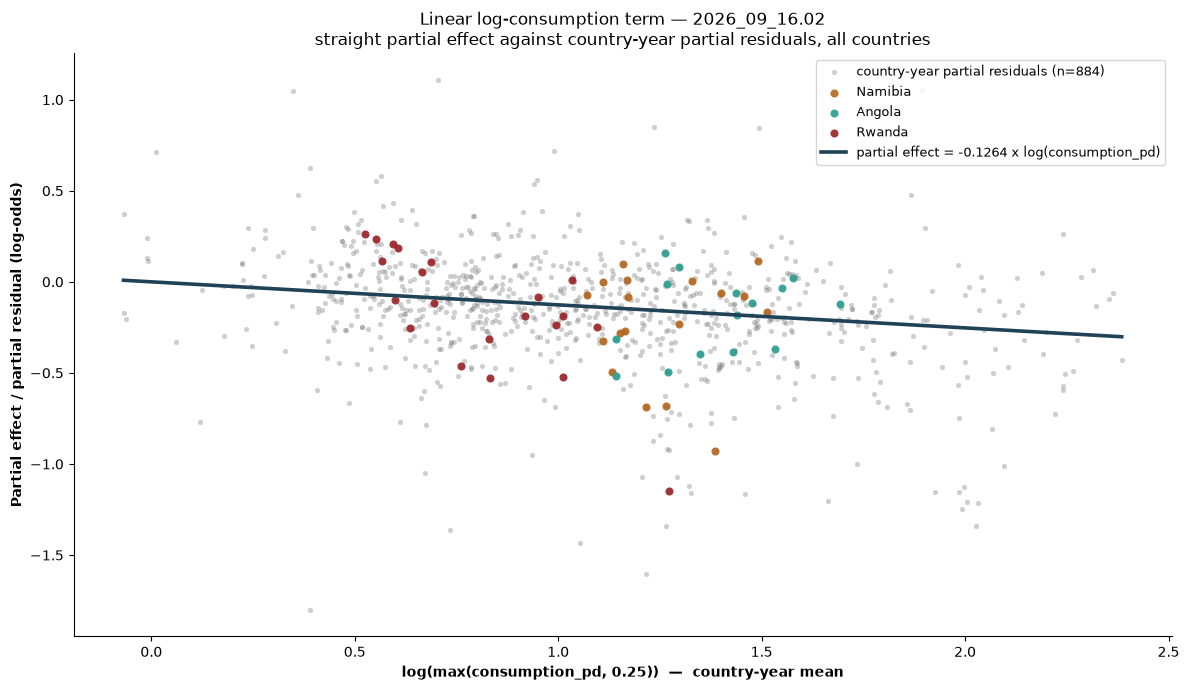

fitted model slope   -0.1264
OLS through points   -0.1831 (intercept +0.0395)
residual sd          0.3135


In [ ]:
# Linear log-consumption term: partial effect line over country-year data ######
# Model LINEAR_MODEL fits a single linear coefficient on the log-transformed
# consumption covariate (transform strategy "log", which floors the value at
# LOG_FLOOR before taking the log). Its partial effect is therefore a straight
# line through the origin,
#     partial effect = beta * log(max(consumption_pd, LOG_FLOOR))
#
# The background points are PARTIAL RESIDUALS, so they sit on the same log-odds
# scale as that line. For each country and birth year:
#     resid = logit(observed neonatal mortality)
#             - intercept
#             - beta_birth_year * birth_year
#             - ranef[country]
#             - mean sex contribution in that cell
# i.e. the observed outcome with every fitted term except consumption removed.
# Country-years with no deaths have an undefined logit and are dropped.
from pathlib import Path

import yaml

LINEAR_MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
LINEAR_MODEL = "2026_09_16.02"
LINEAR_VAR = "consumption_pd"
LOG_FLOOR = 0.25  # LogScaler floor in rra_climate_health.transforms.scaling
LINEAR_MIN_OBS = 25  # births needed for a country-year to be plotted
HIGHLIGHT_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
HIGHLIGHT_COLORS = ["#b5651d", "#2a9d8f", "#9b2226"]

_ldir = LINEAR_MODEL_ROOT / LINEAR_MODEL
_lcoefs = pd.read_parquet(_ldir / "base_model_coefs.parquet")["Estimate"]
_lranef = pd.read_parquet(_ldir / "base_model_ranef.parquet")["offset"]
_lspec = yaml.safe_load((_ldir / "specification.yaml").read_text())
_strategy = [
    p["transform"]["strategy"] for p in _lspec["predictors"] if p["name"] == LINEAR_VAR
][0]
if _strategy != "log":
    raise ValueError(f"{LINEAR_MODEL} uses transform strategy '{_strategy}', not 'log'")

beta_cons = float(_lcoefs[LINEAR_VAR])
beta_year = float(_lcoefs["birth_year"])
beta_sex2 = float(_lcoefs["C(sex_id)2"])
intercept = float(_lcoefs["(Intercept)"])
print(
    f"{LINEAR_MODEL}: beta(log {LINEAR_VAR}) = {beta_cons:.6f}"
    f"  -> {100 * (np.exp(beta_cons * np.log(2)) - 1):.2f}% per doubling of consumption"
)

# Country-year cells ###########################################################
_cells = df_raw.assign(
    _x=np.log(np.maximum(df_raw[LINEAR_VAR], LOG_FLOOR)),
    _sex2=(df_raw["sex_id"].astype(int) == 2).astype(float),
)
_cells = (
    _cells.groupby(["ihme_loc_id", "location_name", "birth_year"], as_index=False)
    .agg(
        x=("_x", "mean"),
        nmr=("neonatal_mortality", "mean"),
        deaths=("neonatal_mortality", "sum"),
        frac_female=("_sex2", "mean"),
        n=("neonatal_mortality", "size"),
    )
    .query("n >= @LINEAR_MIN_OBS")
)
_dropped = int((_cells["deaths"] == 0).sum())
_cells = _cells[_cells["deaths"] > 0].copy()
_cells["resid"] = (
    np.log(_cells["nmr"] / (1 - _cells["nmr"]))
    - intercept
    - beta_year * _cells["birth_year"]
    - _cells["ihme_loc_id"].map(_lranef).astype(float)
    - beta_sex2 * _cells["frac_female"]
)
print(
    f"  {len(_cells):,} country-years across {_cells['ihme_loc_id'].nunique()} "
    f"countries ({_dropped} dropped with zero deaths)"
)

# Plot #########################################################################
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    _cells["x"],
    _cells["resid"],
    s=14,
    alpha=0.35,
    color="0.45",
    linewidths=0,
    zorder=1,
    label=f"country-year partial residuals (n={len(_cells):,})",
)
for country, colour in zip(HIGHLIGHT_COUNTRIES, HIGHLIGHT_COLORS):
    sub = _cells[_cells["location_name"] == country]
    ax.scatter(
        sub["x"],
        sub["resid"],
        s=34,
        alpha=0.9,
        color=colour,
        linewidths=0,
        zorder=3,
        label=country,
    )

x_line = np.linspace(_cells["x"].min(), _cells["x"].max(), 200)
ax.plot(
    x_line,
    beta_cons * x_line,
    color="#1f4257",
    lw=2.6,
    zorder=4,
    label=f"partial effect = {beta_cons:.4f} x log({LINEAR_VAR})",
)

ax.set_xlabel(
    f"log(max({LINEAR_VAR}, {LOG_FLOOR}))  —  country-year mean", fontweight="bold"
)
ax.set_ylabel("Partial effect / partial residual (log-odds)", fontweight="bold")
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(loc="upper right", fontsize=9)
ax.set_title(
    f"Linear log-consumption term — {LINEAR_MODEL}\n"
    f"straight partial effect against country-year partial residuals, all countries",
    fontsize=12,
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}linear_log_consumption_partial_effect.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# How the fitted slope compares with the spread of the residuals ###############
_fit = np.polyfit(_cells["x"], _cells["resid"], 1)
print(
    f"fitted model slope   {beta_cons:+.4f}\n"
    f"OLS through points   {_fit[0]:+.4f} (intercept {_fit[1]:+.4f})\n"
    f"residual sd          {_cells['resid'].std():.4f}"
)

Compare the spline on consumption_pd (2026_09_14.02) with the linear term behind INFERENCE_FILE_09_17

spline model 2026_09_14.02: effect at x=6.36e-05 is +0.1577
linear model 2026_09_16.04 (results 2026_09_17.01): beta = -0.041182 per $1/day
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/spline_vs_linear_consumption_pd.pdf


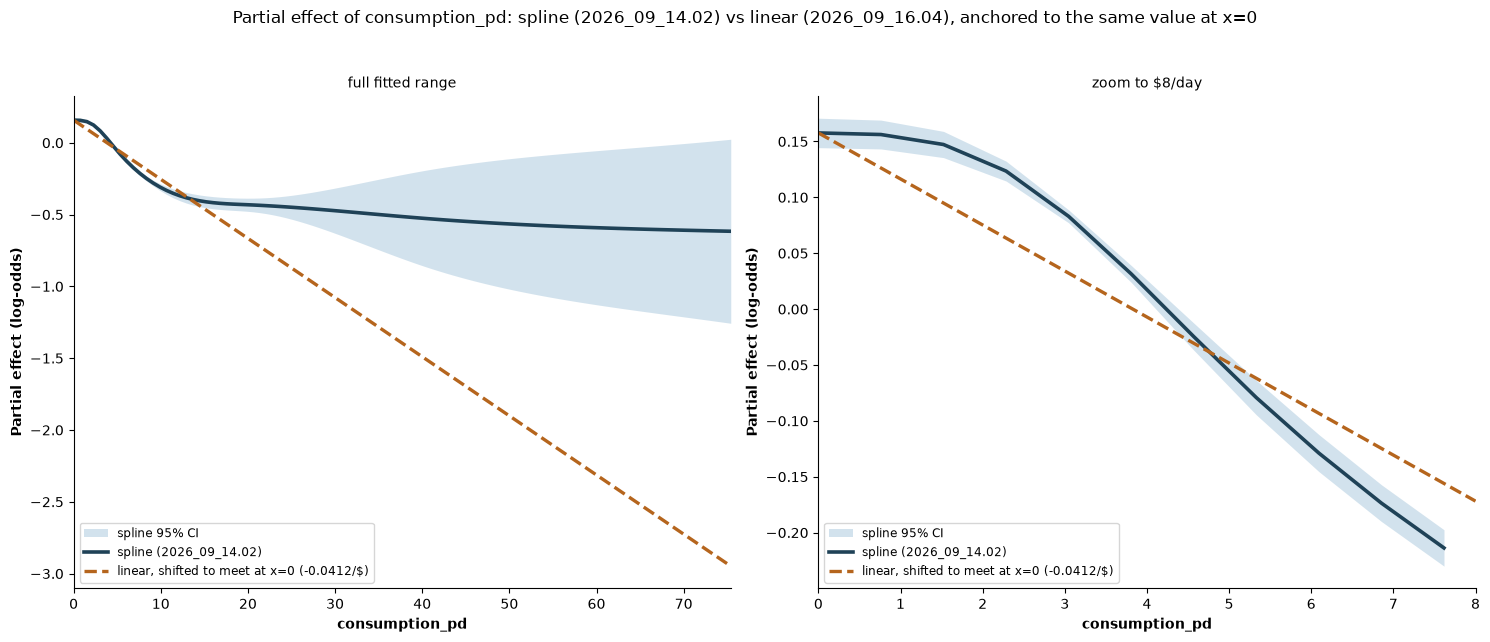

 consumption_pd  spline  linear_shifted  difference
            0.5  0.1567          0.1371     -0.0196
            1.0  0.1534          0.1165     -0.0369
            2.0  0.1324          0.0753     -0.0571
            3.0  0.0855          0.0341     -0.0514
            5.0 -0.0554         -0.0483      0.0072
            8.0 -0.2317         -0.1718      0.0599
           10.0 -0.3113         -0.2542      0.0571
           20.0 -0.4317         -0.6660     -0.2343
           40.0 -0.5253         -1.4896     -0.9643
           75.0 -0.6156         -2.9310     -2.3154

local spline slope (log-odds per $1/day) vs the constant linear slope -0.0412:
  at $  1.0/day  spline -0.0210   ratio  0.51x
  at $  2.0/day  spline -0.0314   ratio  0.76x
  at $  5.0/day  spline -0.0583   ratio  1.42x
  at $ 10.0/day  spline -0.0381   ratio  0.93x
  at $ 20.0/day  spline -0.0120   ratio  0.29x


In [4]:
# Spline vs linear term on consumption_pd ######################################
# Overlays the fitted spline from CMP_SPLINE_MODEL with the single linear
# coefficient from the model behind INFERENCE_FILE_09_17. Both are partial
# effects on the log-odds scale, but a linear term is only identified up to an
# intercept that the model absorbs, so the line is shifted to meet the spline at
# x = 0:
#     line(x) = spline_effect(x_min) + beta * x
# That makes the two directly comparable as slopes, which is the point here.
# The model version behind the results file is read from its results spec rather
# than assumed, since results and model versions differ.

CMP_MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
CMP_SPLINE_MODEL = "2026_09_14.02"  # spline on consumption_pd
CMP_LINEAR_RESULTS = INFERENCE_FILE_09_17  # linear on consumption_pd
CMP_VAR = "consumption_pd"
CMP_ZOOM_XMAX = 8.0

# Spline ######################################################################
_cs = pd.read_parquet(
    CMP_MODEL_ROOT / CMP_SPLINE_MODEL / f"spline_effect_{CMP_VAR}.parquet"
)
_cs_lo = _cs["effect"] - 1.96 * _cs["se"]
_cs_hi = _cs["effect"] + 1.96 * _cs["se"]
anchor = float(_cs["effect"].iloc[0])  # spline value at the low end of x

# Linear term #################################################################
_lin_results = Path(CMP_LINEAR_RESULTS).parent
_lin_version = yaml.safe_load((_lin_results / "results_spec.yaml").read_text())[
    "version"
]["model"]
_lin_dir = CMP_MODEL_ROOT / _lin_version
_lin_spec = yaml.safe_load((_lin_dir / "specification.yaml").read_text())
_lin_pred = [p for p in _lin_spec["predictors"] if p["name"] == CMP_VAR][0]
if _lin_pred["spline"] is not None or _lin_pred["transform"]["strategy"] != "identity":
    raise ValueError(
        f"{_lin_version} is not a linear identity term on {CMP_VAR}: "
        f"spline={_lin_pred['spline']}, "
        f"strategy={_lin_pred['transform']['strategy']}"
    )
beta_lin = float(
    pd.read_parquet(_lin_dir / "base_model_coefs.parquet")["Estimate"][CMP_VAR]
)

print(
    f"spline model {CMP_SPLINE_MODEL}: effect at x={_cs['value'].iloc[0]:.4g} is {anchor:+.4f}"
)
print(
    f"linear model {_lin_version} (results {_lin_results.name}): beta = {beta_lin:+.6f} per $1/day"
)

# Plot ########################################################################
fig, axes = plt.subplots(ncols=2, figsize=(15, 6.5))

for ax, x_max, tag in (
    (axes[0], float(_cs["value"].max()), "full fitted range"),
    (axes[1], CMP_ZOOM_XMAX, f"zoom to ${CMP_ZOOM_XMAX:.0f}/day"),
):
    keep = _cs["value"] <= x_max
    ax.fill_between(
        _cs.loc[keep, "value"],
        _cs_lo[keep],
        _cs_hi[keep],
        color="#9dc0d8",
        alpha=0.45,
        linewidth=0,
        label="spline 95% CI",
    )
    ax.plot(
        _cs.loc[keep, "value"],
        _cs.loc[keep, "effect"],
        color="#1f4257",
        lw=2.6,
        label=f"spline ({CMP_SPLINE_MODEL})",
    )
    x_line = np.linspace(0, x_max, 200)
    ax.plot(
        x_line,
        anchor + beta_lin * x_line,
        color="#b5651d",
        lw=2.4,
        ls="--",
        label=f"linear, shifted to meet at x=0 ({beta_lin:+.4f}/$)",
    )
    ax.set_xlim(0, x_max)
    if tag.startswith("zoom"):
        ax.set_ylim(
            min(_cs_lo[keep].min(), anchor + beta_lin * x_max) - 0.02,
            max(_cs_hi[keep].max(), anchor) + 0.02,
        )
    ax.set_xlabel(CMP_VAR, fontweight="bold")
    ax.set_ylabel("Partial effect (log-odds)", fontweight="bold")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_title(tag, fontsize=10)
    ax.legend(loc="lower left", fontsize=8.5)

fig.suptitle(
    f"Partial effect of {CMP_VAR}: spline ({CMP_SPLINE_MODEL}) vs linear "
    f"({_lin_version}), anchored to the same value at x=0",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))

plot_path = f"{PLOT_OUTPUT}spline_vs_linear_{CMP_VAR}.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Where the two agree and where they part ways #################################
_cmp = pd.DataFrame({CMP_VAR: [0.5, 1, 2, 3, 5, 8, 10, 20, 40, 75]})
_cmp["spline"] = np.interp(_cmp[CMP_VAR], _cs["value"], _cs["effect"])
_cmp["linear_shifted"] = anchor + beta_lin * _cmp[CMP_VAR]
_cmp["difference"] = _cmp["linear_shifted"] - _cmp["spline"]
print(_cmp.round(4).to_string(index=False))

_slope_grid = np.array([1.0, 2.0, 5.0, 10.0, 20.0])
_local = np.gradient(np.interp(_slope_grid, _cs["value"], _cs["effect"]), _slope_grid)
print(
    "\nlocal spline slope (log-odds per $1/day) vs the constant linear slope "
    f"{beta_lin:+.4f}:"
)
for x, sl in zip(_slope_grid, _local):
    print(f"  at ${x:>5.1f}/day  spline {sl:+.4f}   ratio {sl / beta_lin:5.2f}x")

In [4]:
# Country-year aggregate of the training data ##################################
# One row per country and birth year. The two log columns are the log OF the
# aggregate (log of the mean, log of the median), not the mean of the logged
# values - those differ, and the model's log transform uses the latter.
# consumption_pd is strictly positive in this dataset (min 6.36e-05), so no
# floor is needed before taking logs.
df_agg_cy = df_raw.groupby(
    ["ihme_loc_id", "location_name", "birth_year"], as_index=False
).agg(
    neonatal_mortality=("neonatal_mortality", "mean"),
    consumption_pd_mean=("consumption_pd", "mean"),
    consumption_pd_median=("consumption_pd", "median"),
    n_births=("neonatal_mortality", "size"),
)
df_agg_cy["log_consumption_pd_mean"] = np.log(df_agg_cy["consumption_pd_mean"])
df_agg_cy["log_consumption_pd_median"] = np.log(df_agg_cy["consumption_pd_median"])

print(
    f"{len(df_agg_cy):,} country-years across "
    f"{df_agg_cy['ihme_loc_id'].nunique()} countries, "
    f"birth_year {df_agg_cy['birth_year'].min()}-{df_agg_cy['birth_year'].max()}"
)
df_agg_cy.head()

918 country-years across 60 countries, birth_year 1985-2023


,ihme_loc_id,location_name,birth_year,neonatal_mortality,consumption_pd_mean,consumption_pd_median,n_births,log_consumption_pd_mean,log_consumption_pd_median
0,AGO,Angola,2001,0.000000,5.753322,6.467961,5,1.749777,1.866861
1,AGO,Angola,2002,0.019802,5.306616,3.421320,404,1.668954,1.230026
2,AGO,Angola,2003,0.019194,4.641974,3.231227,521,1.535140,1.172862
3,AGO,Angola,2004,0.033482,5.639099,3.534721,448,1.729724,1.262634
4,AGO,Angola,2005,0.022599,4.799794,3.139259,531,1.568573,1.143987


In [5]:
# Binomial GLMM: mortality ~ log median consumption, weighted by births #######
# A binomial GLM with a logit link, so the outcome stays a proportion and the
# link does the transforming - no logit of the observed rate, which means the
# country-years with no deaths are kept rather than dropped. Each cell is
# weighted by n_births, so a country-year built on 4,000 births counts for as
# much more than one built on 40 as its precision deserves.
#
# statsmodels has no binomial mixed model (its MixedLM is Gaussian only), so
# lme4::glmer is driven directly through rpy2.
#
# ---------------------------------------------------------------------------
# WHY THE CACHE
# rpy2 here is compiled against gbd_env but dlopens the R inside the cgf env,
# over a force-loaded foreign libstdc++. That mix segfaults the kernel at
# random - measured at roughly a coin flip per run, landing on whatever R call
# happens to be executing. A segfault takes the whole kernel with it.
#
# So the fit is written to MM_CACHE on success and reloaded from there
# afterwards. Once one run gets through, this cell never touches R again and
# the rest of the notebook runs on any kernel. Set MM_REFIT = True to force it
# back through R (e.g. after changing the data or the formula).
# ---------------------------------------------------------------------------
import json
import os

MM_X = "log_consumption_pd_median"
MM_WEIGHT = "n_births"
MM_CACHE = Path("mm_glmm_fit.json")  # beside this notebook
MM_REFIT = False

mm_df = df_agg_cy.dropna(subset=["neonatal_mortality", MM_X, MM_WEIGHT]).copy()
print(
    f"{len(mm_df):,} country-years, {mm_df['ihme_loc_id'].nunique()} countries, "
    f"{int(mm_df[MM_WEIGHT].sum()):,} births; "
    f"{int((mm_df['neonatal_mortality'] == 0).sum())} cells with zero deaths are "
    f"kept (the binomial likelihood handles them)"
)

# What the cache has to match for it to still describe this data
mm_signature = {
    "x": MM_X,
    "weight": MM_WEIGHT,
    "n_rows": int(len(mm_df)),
    "n_groups": int(mm_df["ihme_loc_id"].nunique()),
    "outcome_sum": round(
        float((mm_df["neonatal_mortality"] * mm_df[MM_WEIGHT]).sum()), 6
    ),
    "x_sum": round(float(mm_df[MM_X].sum()), 6),
}

_cached = None
if MM_CACHE.exists() and not MM_REFIT:
    _c = json.loads(MM_CACHE.read_text())
    if _c.get("signature") == mm_signature:
        _cached = _c
    else:
        print(f"cache at {MM_CACHE} was fitted on different data - refitting in R")

if _cached is not None:
    mm_fixef = _cached["fixef"]
    mm_ranef = _cached["ranef"]
    mm_ranef_sd = _cached["ranef_sd"]
    mm_se = _cached["se"]
    print(f"loaded the fit from {MM_CACHE} (fitted {_cached['fitted_at']}); R not used")
else:
    # Run this on the "gbd_env (with R)" kernel. gbd_env ships no R of its own,
    # and R 4.4.3 needs a newer libstdc++ than the system one that pandas and
    # numpy load first - so that kernelspec sets both R_HOME and LD_PRELOAD in
    # its env block (~/.local/share/jupyter/kernels/gbd_env_r/kernel.json).
    #
    # LD_PRELOAD has to be set before the process starts, so a plain gbd_env
    # kernel cannot be rescued from inside the notebook: importing rpy2 there
    # fails outright. The check below turns that into a readable error.
    #
    # R_HOME is read once, when rpy2.rinterface_lib.openrlib is first imported,
    # and cached on that module. If rpy2 was ever imported in this kernel
    # without it set, the cached value stays None and you get "Unable to
    # determine R_HOME" whatever this cell does - restart the kernel then.
    os.environ.setdefault("R_HOME", "/ihme/homes/elyeb/miniconda3/envs/cgf/lib/R")
    if "libstdc++" not in os.environ.get("LD_PRELOAD", ""):
        raise RuntimeError(
            'No cached fit, so this needs the "gbd_env (with R)" kernel. Select '
            "it, restart the kernel and run the notebook from the top."
        )

    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.conversion import localconverter

    ro.r("suppressMessages(library(lme4))")
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv["mm_r_df"] = ro.conversion.py2rpy(
            mm_df[["ihme_loc_id", "neonatal_mortality", MM_X, MM_WEIGHT]]
        )
    ro.globalenv["mm_fit_r"] = ro.r(
        f"glmer(neonatal_mortality ~ {MM_X} + (1 | ihme_loc_id), data = mm_r_df, "
        f'family = binomial(link = "logit"), weights = {MM_WEIGHT})'
    )
    print(ro.r("paste(capture.output(summary(mm_fit_r)), collapse = '\\n')")[0])

    # Pull the fit into python so the plotting cells never touch R
    _fx = ro.r("fixef(mm_fit_r)")
    mm_fixef = dict(zip(list(_fx.names), [float(v) for v in _fx]))
    _se = ro.r("sqrt(diag(as.matrix(vcov(mm_fit_r))))")
    mm_se = dict(zip(list(_se.names), [float(v) for v in _se]))
    mm_ranef_sd = float(ro.r('attr(VarCorr(mm_fit_r)$ihme_loc_id, "stddev")')[0])
    with localconverter(ro.default_converter + pandas2ri.converter):
        _rf = ro.conversion.rpy2py(ro.r("as.data.frame(ranef(mm_fit_r))"))
    mm_ranef = dict(zip(_rf["grp"].astype(str), _rf["condval"].astype(float)))

    MM_CACHE.write_text(
        json.dumps(
            {
                "signature": mm_signature,
                "fitted_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
                "formula": f"neonatal_mortality ~ {MM_X} + (1 | ihme_loc_id)",
                "fixef": mm_fixef,
                "se": mm_se,
                "ranef_sd": mm_ranef_sd,
                "ranef": mm_ranef,
            },
            indent=1,
        )
    )
    print(f"\nfit cached to {MM_CACHE.resolve()} - later runs skip R entirely")


def mm_predict(frame, use_ranef=True):
    """Fitted mortality on the probability scale (inverse logit link)."""
    z = mm_fixef["(Intercept)"] + mm_fixef[MM_X] * frame[MM_X]
    if use_ranef:
        z = z + frame["ihme_loc_id"].map(mm_ranef).fillna(0.0)
    return 1 / (1 + np.exp(-z))


print(
    f"\nslope on {MM_X}: {mm_fixef[MM_X]:+.6f} log-odds per log unit "
    f"(se {mm_se[MM_X]:.6f})"
    f"\n  -> {100 * (np.exp(mm_fixef[MM_X] * np.log(2)) - 1):+.2f}% change in the "
    f"odds of neonatal death per doubling of median consumption"
)
print(
    f"random intercept sd: {mm_ranef_sd:.4f} over {len(mm_ranef)} countries; "
    f"intercept {mm_fixef['(Intercept)']:+.4f}"
)

918 country-years, 60 countries, 1,711,538 births; 28 cells with zero deaths are kept (the binomial likelihood handles them)
loaded the fit from mm_glmm_fit.json (fitted 2026-09-17 15:43); R not used

slope on log_consumption_pd_median: -0.645337 log-odds per log unit (se 0.028640)
  -> -36.07% change in the odds of neonatal death per doubling of median consumption
random intercept sd: 0.3286 over 60 countries; intercept -2.9052


Row-1 covariate trajectories with the country-year mixed model overlaid in black

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/row1_with_mixed_model.pdf


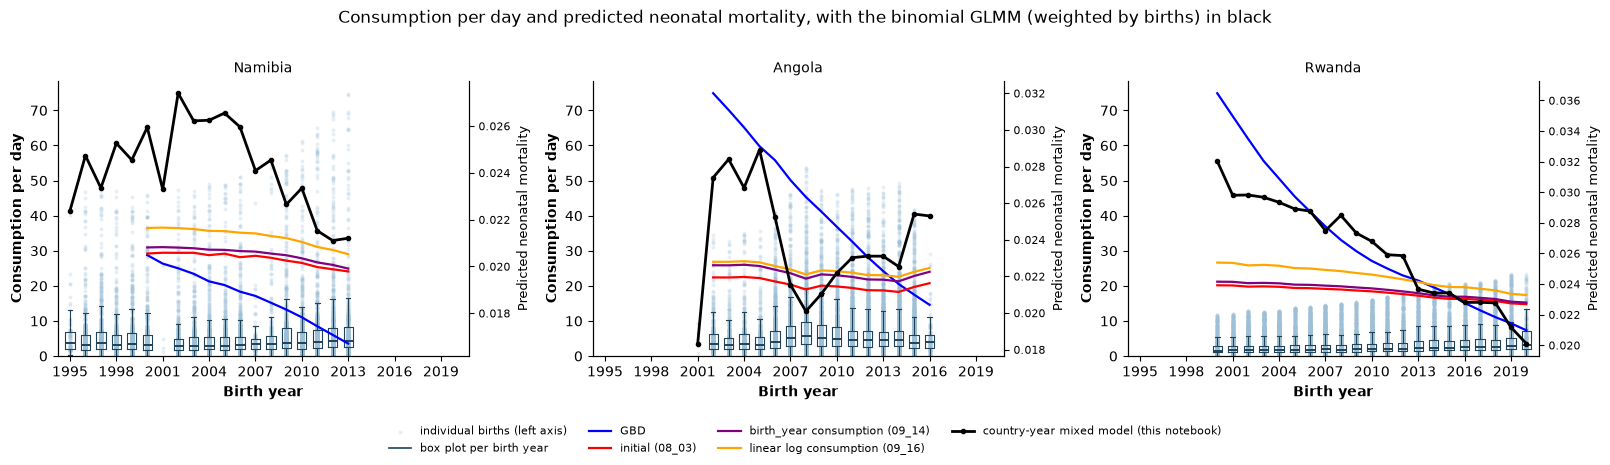

                   min      max
location_name                  
Angola         0.01833  0.02891
Namibia        0.02111  0.02740
Rwanda         0.02011  0.03204


In [6]:
# Row-1 trajectories, with the country-year mixed model overlaid ##############
# Same content as the first row of the covariate-trajectory figure: one column
# per country, consumption_pd against birth_year on the left axis (individual
# births plus a box plot per year), and predicted neonatal mortality on a twin
# right axis. Adds the binomial GLMM fitted in this notebook as a BLACK line.
#
# That model is fitted on country-year aggregates, so its prediction for a cell
# is  expit(intercept + slope * log median consumption + random intercept).
# The other series come from raster inference and are sex-averaged.
MM_COLOR = "black"
MM_LABEL = "country-year mixed model (this notebook)"
R1_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
R1_MIN_OBS = 25
R1_POINT_COLOR = "#9dc0d8"
R1_BOX_COLOR = "#1f4257"
R1_PRED_COLS = {
    "prevalence_gbd": ("blue", "GBD"),
    "prevalence_initial": ("red", "initial (08_03)"),
    "prevalence_birth_year_consumption": ("purple", "birth_year consumption (09_14)"),
    "prevalence_linear_log_consumption": ("orange", "linear log consumption (09_16)"),
}


def _r1_mean_draw(frame):
    draw_cols = [c for c in frame.columns if c.startswith("draw_")]
    out = frame[[c for c in frame.columns if "draw_" not in c]].copy()
    out["prevalence"] = frame[draw_cols].mean(axis=1)
    return out


# Inference / GBD series, rebuilt here so the cell stands on its own ###########
_r1_key = ["location_id", "year_id", "sex_id"]
_r1_sources = {
    "prevalence_gbd": (GBD_FILE, False),
    "prevalence_initial": (INFERENCE_FILE_08_03, True),
    "prevalence_birth_year_consumption": (INFERENCE_FILE_09_14, True),
    "prevalence_linear_log_consumption": (INFERENCE_FILE_09_16, True),
}
r1_pred = None
for _col, (_path, _is_draws) in _r1_sources.items():
    _f = pd.read_parquet(_path).reset_index()
    _f = (
        _r1_mean_draw(_f).rename(columns={"prevalence": _col})
        if _is_draws
        else _f.rename(columns={"gbd_mean_prevalence": _col})
    )
    _f = _f[_r1_key + [_col]]
    r1_pred = _f if r1_pred is None else r1_pred.merge(_f, on=_r1_key, how="inner")
r1_pred = (
    r1_pred.merge(locs[["location_id", "location_name"]], on="location_id", how="left")
    .query("location_name in @R1_COUNTRIES")
    .groupby(["location_name", "year_id"], as_index=False)[list(R1_PRED_COLS)]
    .mean()
)

# Mixed-model fitted values, including the country random intercept ############
# mm_predict inverts the logit link, so the line stays in the same mortality
# units as the inference series on the right axis.
mm_pred = mm_df[["ihme_loc_id", "location_name", "birth_year"]].copy()
mm_pred["mm_fitted"] = mm_predict(mm_df)
mm_pred = mm_pred.query("location_name in @R1_COUNTRIES")

# Shared limits ################################################################
_r1_sel = df_raw[df_raw["location_name"].isin(R1_COUNTRIES)]
_r1_counts = _r1_sel.groupby(["location_name", "birth_year"]).size()
_r1_years = _r1_counts[_r1_counts >= R1_MIN_OBS].index.get_level_values("birth_year")
r1_year_lim = (_r1_years.min() - 0.8, _r1_years.max() + 0.8)
r1_ylim = (0.0, float(_r1_sel["consumption_pd"].max()) * 1.05)

# Plot #########################################################################
fig, axes = plt.subplots(
    ncols=len(R1_COUNTRIES), figsize=(5.4 * len(R1_COUNTRIES), 4.6)
)
axes = np.atleast_1d(axes)
handles, labels = [], []

for ax, country in zip(axes, R1_COUNTRIES):
    sub = df_raw[df_raw["location_name"] == country]
    ax.scatter(
        sub["birth_year"],
        sub["consumption_pd"],
        s=8,
        alpha=0.25,
        color=R1_POINT_COLOR,
        linewidths=0,
        zorder=1,
        label="individual births (left axis)",
    )

    counts = sub.groupby("birth_year").size()
    kept_years = counts[counts >= R1_MIN_OBS].index
    if len(kept_years):
        ax.boxplot(
            [
                sub.loc[sub["birth_year"] == yr, "consumption_pd"].dropna().to_numpy()
                for yr in kept_years
            ],
            positions=list(kept_years),
            widths=0.6,
            manage_ticks=False,
            showfliers=False,
            zorder=2,
            boxprops={"color": R1_BOX_COLOR, "linewidth": 0.8},
            whiskerprops={"color": R1_BOX_COLOR, "linewidth": 0.8},
            capprops={"color": R1_BOX_COLOR, "linewidth": 0.8},
            medianprops={"color": R1_BOX_COLOR, "linewidth": 1.4},
        )

    y0, y1 = kept_years.min(), kept_years.max()
    p = r1_pred[
        (r1_pred["location_name"] == country) & r1_pred["year_id"].between(y0, y1)
    ].sort_values("year_id")
    m = mm_pred[mm_pred["location_name"] == country].sort_values("birth_year")

    ax2 = ax.twinx()
    for pred_col, (colour, label) in R1_PRED_COLS.items():
        ax2.plot(p["year_id"], p[pred_col], color=colour, lw=1.6, zorder=3, label=label)
    ax2.plot(
        m["birth_year"],
        m["mm_fitted"],
        color=MM_COLOR,
        lw=2.0,
        marker="o",
        ms=3,
        zorder=4,
        label=MM_LABEL,
    )
    ax2.set_ylabel("Predicted neonatal mortality", fontsize=9)
    ax2.tick_params(labelsize=8)
    ax2.spines["top"].set_visible(False)

    ax.set_xlim(*r1_year_lim)
    ax.set_ylim(*r1_ylim)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Birth year", fontweight="bold")
    ax.set_ylabel("Consumption per day", fontweight="bold")
    ax.set_title(country, fontsize=10)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    if not handles:
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles, labels = h1 + h2, l1 + l2
        handles.insert(1, plt.Line2D([], [], color=R1_BOX_COLOR, lw=1.2))
        labels.insert(1, "box plot per birth year")

fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, frameon=False)
fig.suptitle(
    "Consumption per day and predicted neonatal mortality, with the "
    "binomial GLMM (weighted by births) in black",
    fontsize=12,
)
fig.tight_layout(rect=(0, 0.10, 1, 0.97))

plot_path = f"{PLOT_OUTPUT}row1_with_mixed_model.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

print(
    mm_pred.groupby("location_name")["mm_fitted"]
    .agg(["min", "max"])
    .round(5)
    .to_string()
)

In [ ]:
# Median consumption vs predictions: mixed model, then GBD #####################
# Two rows, one panel each, over every country-year the GLMM was fitted
# on (all countries, not just the three focus ones).
#   row 1: the mixed model's fitted value, intercept + slope * median + ranef
#   row 2: GBD prevalence for the same country-year, averaged over sex
# GBD is indexed by year_id, so it is joined to birth_year.
SC_POINT_COLOR = "#1f4257"

# Mixed-model fitted values, including the country random intercept
# The model uses a logit link, so mm_predict inverts it back to mortality; the
# x axis stays the raw median so it is comparable with GBD below.
sc = mm_df[
    ["ihme_loc_id", "location_name", "birth_year", "consumption_pd_median"]
].copy()
sc["mm_pred"] = mm_predict(mm_df)

# GBD for the same country-years, averaged over sex
_sc_gbd = (
    pd.read_parquet(GBD_FILE)
    .reset_index()
    .groupby(["location_id", "year_id"], as_index=False)["gbd_mean_prevalence"]
    .mean()
    .merge(locs[["location_id", "ihme_loc_id"]], on="location_id", how="left")
    .rename(columns={"year_id": "birth_year", "gbd_mean_prevalence": "gbd_pred"})
)
sc = sc.merge(
    _sc_gbd[["ihme_loc_id", "birth_year", "gbd_pred"]],
    on=["ihme_loc_id", "birth_year"],
    how="left",
)

sc_specs = [
    ("mm_pred", "Mixed-model predicted mortality"),
    ("gbd_pred", "GBD predicted mortality"),
]

fig, axes = plt.subplots(nrows=len(sc_specs), ncols=1, figsize=(9, 9))
axes = np.atleast_1d(axes)

for ax, (y_col, y_label) in zip(axes, sc_specs):
    d = sc.dropna(subset=["consumption_pd_median", y_col])
    ax.scatter(
        d["consumption_pd_median"],
        d[y_col],
        s=16,
        alpha=0.4,
        color=SC_POINT_COLOR,
        linewidths=0,
    )
    r = d[["consumption_pd_median", y_col]].corr().iloc[0, 1]
    ax.set_title(
        f"{y_label} vs median consumption_pd  " f"(r = {r:.2f}, n = {len(d):,})",
        fontsize=11,
    )
    # anchored at zero; note the mixed model can predict below 0, see the print
    ax.set_ylim(bottom=0.0)
    ax.set_xlabel("Median consumption per day (country-year)", fontweight="bold")
    ax.set_ylabel(y_label, fontweight="bold")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}median_consumption_vs_predictions.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

print(
    sc[["consumption_pd_median", "mm_pred", "gbd_pred"]]
    .describe()
    .loc[["count", "mean", "min", "max"]]
    .round(4)
    .to_string()
)
for _c in ("mm_pred", "gbd_pred"):
    _n = int((sc[_c] < 0).sum())
    if _n:
        print(
            f"note: {_n} {_c} value(s) below 0 are outside the anchored y range "
            f"(min {sc[_c].min():.4f})"
        )

print("\ncorrelation with median consumption_pd:")
print(
    sc[["consumption_pd_median", "mm_pred", "gbd_pred"]]
    .corr()["consumption_pd_median"]
    .round(3)
    .to_string()
)

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/observed_vs_gbd_country_year.pdf


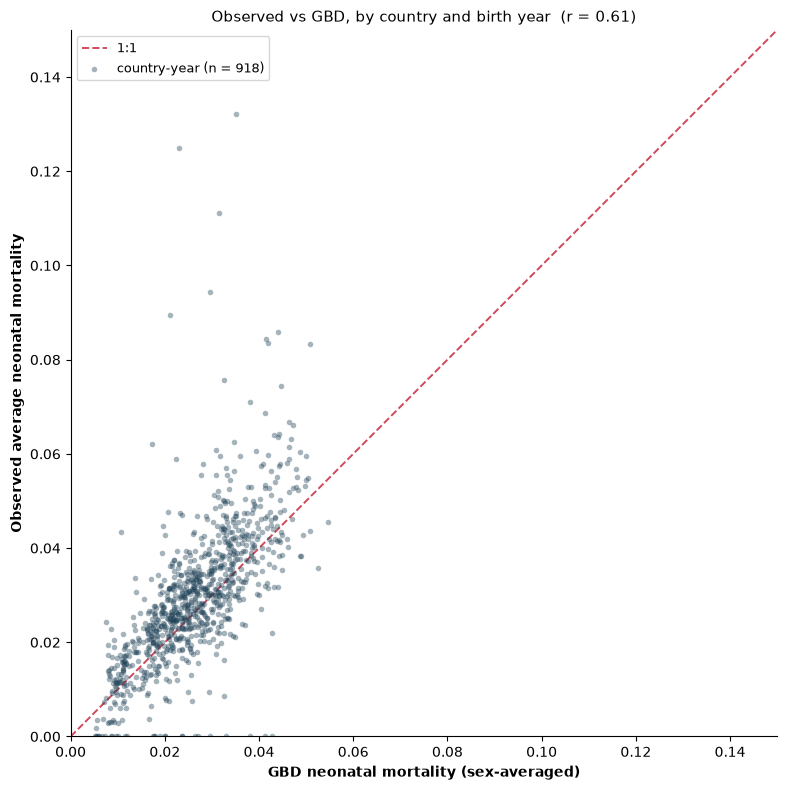

note: 1 country-year(s) fall outside the 0.15 axes:
location_name  birth_year  neonatal_mortality    gbd  n_births
      Namibia        2001                0.25 0.0201         4
       neonatal_mortality       gbd  difference
count            918.0000  918.0000    918.0000
mean               0.0300    0.0263      0.0037
std                0.0168    0.0100      0.0133
min                0.0000    0.0052     -0.0427
max                0.2500    0.0547      0.2299

observed above GBD in 66.2% of country-years;  mean difference +0.0037


In [16]:
# Observed country-year mortality vs GBD ######################################
# y: the average neonatal mortality actually seen in the training data for that
#    country and birth year (df_agg_cy, so all 918 cells - no logit is taken
#    here, which means the zero-death cells that the models drop are kept).
# x: GBD prevalence for the same country-year, averaged over sex. GBD is indexed
#    by year_id, so it is joined to birth_year.
# Axes share one range anchored at 0 and a 1:1 line is drawn, so distance from
# the diagonal reads directly as disagreement.
OBS_POINT_COLOR = "#1f4257"

obs_gbd = df_agg_cy[
    ["ihme_loc_id", "location_name", "birth_year", "neonatal_mortality", "n_births"]
].merge(
    pd.read_parquet(GBD_FILE)
    .reset_index()
    .groupby(["location_id", "year_id"], as_index=False)["gbd_mean_prevalence"]
    .mean()
    .merge(locs[["location_id", "ihme_loc_id"]], on="location_id", how="left")
    .rename(columns={"year_id": "birth_year", "gbd_mean_prevalence": "gbd"})[
        ["ihme_loc_id", "birth_year", "gbd"]
    ],
    on=["ihme_loc_id", "birth_year"],
    how="inner",
)

# Zoomed to the bulk of the data; a handful of tiny-n cells sit above this and
# are reported below rather than silently dropped.
AXIS_MAX = 0.15
lim = (0.0, AXIS_MAX)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(lim, lim, color="#d1495b", lw=1.4, ls="--", zorder=1, label="1:1")
ax.scatter(
    obs_gbd["gbd"],
    obs_gbd["neonatal_mortality"],
    s=16,
    alpha=0.4,
    color=OBS_POINT_COLOR,
    linewidths=0,
    zorder=2,
    label=f"country-year (n = {len(obs_gbd):,})",
)
r = obs_gbd[["gbd", "neonatal_mortality"]].corr().iloc[0, 1]
ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.set_aspect("equal")
ax.set_xlabel("GBD neonatal mortality (sex-averaged)", fontweight="bold")
ax.set_ylabel("Observed average neonatal mortality", fontweight="bold")
ax.set_title(f"Observed vs GBD, by country and birth year  (r = {r:.2f})", fontsize=11)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}observed_vs_gbd_country_year.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

_clipped = obs_gbd[
    (obs_gbd["neonatal_mortality"] > AXIS_MAX) | (obs_gbd["gbd"] > AXIS_MAX)
]
if len(_clipped):
    print(f"note: {len(_clipped)} country-year(s) fall outside the {AXIS_MAX} axes:")
    print(
        _clipped[
            ["location_name", "birth_year", "neonatal_mortality", "gbd", "n_births"]
        ]
        .sort_values("neonatal_mortality", ascending=False)
        .round(4)
        .to_string(index=False)
    )

obs_gbd["difference"] = obs_gbd["neonatal_mortality"] - obs_gbd["gbd"]
print(
    obs_gbd[["neonatal_mortality", "gbd", "difference"]]
    .describe()
    .loc[["count", "mean", "std", "min", "max"]]
    .round(4)
    .to_string()
)
print(
    f"\nobserved above GBD in {100 * (obs_gbd['difference'] > 0).mean():.1f}% of "
    f"country-years;  mean difference {obs_gbd['difference'].mean():+.4f}"
)